# Joint Volcano and barplot for pvalue and effect size
jardin de gente -spinetta


In [1]:
from pathlib import Path
import sys
import importlib

project_root = Path("/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project")
src_dir = project_root / "src" / "modules"

if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

import tools_EEG_FE as TEEG_FE

importlib.reload(TEEG_FE)
import matplotlib.pyplot as plt
from matplotlib import font_manager

available_fonts = {f.name for f in font_manager.fontManager.ttflist}

if "Arial" in available_fonts:
    chosen_font = "Arial"
elif "Liberation Sans" in available_fonts:
    chosen_font = "Liberation Sans"   # muy parecida a Arial
else:
    chosen_font = "DejaVu Sans"       # default segura de matplotlib

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": [chosen_font],
    "axes.unicode_minus": False
})

print(f"Using font: {chosen_font}")

Using font: Liberation Sans


In [2]:
from pathlib import Path
import pandas as pd


def load_all_patient_mannwhitney_results(
    root_dir,
    filename_pattern="*.pkl",
    add_source_file=True,
    verbose=True
):
    root_dir = Path(root_dir)

    required_columns = [
        "patient_id",
        "feature",
        "n_preictal",
        "n_ictal",
        "mannwhitney_U_preictal",
        "p_value",
        "neg_log10_p",
        "effect_size_log2_median_fold_change",
        "abs_effect_size_log2_median_fold_change",
        "fold_change_median_ictal_over_preictal",
        "valid_log2_fold_change",
        "median_preictal",
        "median_ictal",
        "mean_preictal",
        "mean_ictal",
        "median_difference_ictal_minus_preictal",
        "mean_difference_ictal_minus_preictal",
        "feature_subcategory",
        "feature_color",
        "result",
    ]

    pkl_files = sorted(root_dir.rglob(filename_pattern))

    if len(pkl_files) == 0:
        raise FileNotFoundError(f"No pkl files found in: {root_dir}")

    dfs = []
    skipped_files = []

    for pkl_path in pkl_files:
        try:
            df = pd.read_pickle(pkl_path)

            if not isinstance(df, pd.DataFrame):
                skipped_files.append((pkl_path, "Not a dataframe"))
                continue

            missing_cols = [col for col in required_columns if col not in df.columns]

            if missing_cols:
                skipped_files.append((pkl_path, f"Missing columns: {missing_cols}"))
                continue

            df = df.copy()

            if add_source_file:
                df["source_file"] = str(pkl_path)

            dfs.append(df)

        except Exception as e:
            skipped_files.append((pkl_path, str(e)))

    if verbose:
        print(f"Found {len(pkl_files)} pkl files")
        print(f"Loaded {len(dfs)} valid dataframe files")
        print(f"Skipped {len(skipped_files)} files")

        if skipped_files:
            print("\nSkipped files:")
            for path, reason in skipped_files:
                print(f"- {path.name}: {reason}")

    if len(dfs) == 0:
        raise ValueError("No valid dataframes were loaded.")

    df_all = pd.concat(dfs, ignore_index=True)

    if verbose:
        print(f"\nCombined dataframe shape: {df_all.shape}")
        print(f"Patients loaded: {df_all['patient_id'].nunique()}")

    return df_all

In [3]:
root_dir = "/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/pvalue_effectsize"

df_all_mannwhitney = load_all_patient_mannwhitney_results(
    root_dir=root_dir,
    filename_pattern="*.pkl"
)

df_all_mannwhitney.head()

Found 9 pkl files
Loaded 9 valid dataframe files
Skipped 0 files

Combined dataframe shape: (252, 27)
Patients loaded: 9


,patient_id,feature,n_preictal,n_ictal,mannwhitney_U_preictal,p_value,neg_log10_p,effect_size_log2_median_fold_change,abs_effect_size_log2_median_fold_change,fold_change_median_ictal_over_preictal,...,feature_subcategory,feature_color,result,experiment_id,version,date_generated,alpha,n_preictal_windows,n_seizure_windows,source_file
0,10OXG,rms_EEG_SQ_P_SQ_C,357,361,33279.0,3.520386e-29,28.453410,1.172756,1.172756,2.254419,...,Amplitude level and magnitude,#0072B2,Significant difference,10OXG_IN-normalized_npz_FP-fullnpz_W10s_PRE6to...,v01,20260620,0.05,357,361,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
1,10OXG,std_EEG_SQ_P_SQ_C,357,361,33282.0,3.563597e-29,28.448111,1.172690,1.172690,2.254317,...,Amplitude variability,#E69F00,Significant difference,10OXG_IN-normalized_npz_FP-fullnpz_W10s_PRE6to...,v01,20260620,0.05,357,361,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
2,10OXG,var_EEG_SQ_P_SQ_C,357,361,33282.0,3.563597e-29,28.448111,2.345381,2.345381,5.081944,...,Amplitude variability,#E69F00,Significant difference,10OXG_IN-normalized_npz_FP-fullnpz_W10s_PRE6to...,v01,20260620,0.05,357,361,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
3,10OXG,ptp_EEG_SQ_P_SQ_C,357,361,33688.0,1.837749e-28,27.735714,1.208072,1.208072,2.310287,...,Amplitude level and magnitude,#0072B2,Significant difference,10OXG_IN-normalized_npz_FP-fullnpz_W10s_PRE6to...,v01,20260620,0.05,357,361,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
4,10OXG,theta_power_EEG_SQ_P_SQ_C,357,361,34049.0,7.762432e-28,27.110002,1.854789,1.854789,3.616989,...,Band-specific spectral power,#D55E00,Significant difference,10OXG_IN-normalized_npz_FP-fullnpz_W10s_PRE6to...,v01,20260620,0.05,357,361,/home/tperezsanchez/Tomas_PS_DissertationKCL20...


In [44]:
df_all_mannwhitney.columns

Index(['patient_id', 'feature', 'n_preictal', 'n_ictal',
       'mannwhitney_U_preictal', 'p_value', 'neg_log10_p',
       'effect_size_log2_median_fold_change',
       'abs_effect_size_log2_median_fold_change',
       'fold_change_median_ictal_over_preictal', 'valid_log2_fold_change',
       'median_preictal', 'median_ictal', 'mean_preictal', 'mean_ictal',
       'median_difference_ictal_minus_preictal',
       'mean_difference_ictal_minus_preictal', 'feature_subcategory',
       'feature_color', 'result', 'experiment_id', 'version', 'date_generated',
       'alpha', 'n_preictal_windows', 'n_seizure_windows', 'source_file'],
      dtype='object')

In [28]:
df_all_mannwhitney[["patient_id", "feature"]].head(30)

,patient_id,feature
0,10OXG,rms_EEG_SQ_P_SQ_C
1,10OXG,std_EEG_SQ_P_SQ_C
2,10OXG,var_EEG_SQ_P_SQ_C
3,10OXG,ptp_EEG_SQ_P_SQ_C
4,10OXG,theta_power_EEG_SQ_P_SQ_C
5,10OXG,beta_power_EEG_SQ_P_SQ_C
6,10OXG,delta_power_EEG_SQ_P_SQ_C
7,10OXG,gamma_power_EEG_SQ_P_SQ_C
8,10OXG,alpha_power_EEG_SQ_P_SQ_C
9,10OXG,line_length_EEG_SQ_P_SQ_C


In [29]:
df_all_mannwhitney["feature"].unique()

array(['rms_EEG_SQ_P_SQ_C', 'std_EEG_SQ_P_SQ_C', 'var_EEG_SQ_P_SQ_C',
       'ptp_EEG_SQ_P_SQ_C', 'theta_power_EEG_SQ_P_SQ_C',
       'beta_power_EEG_SQ_P_SQ_C', 'delta_power_EEG_SQ_P_SQ_C',
       'gamma_power_EEG_SQ_P_SQ_C', 'alpha_power_EEG_SQ_P_SQ_C',
       'line_length_EEG_SQ_P_SQ_C', 'delta_power_EEG_SQ_D_SQ_C',
       'theta_power_EEG_SQ_D_SQ_C', 'rms_EEG_SQ_D_SQ_C',
       'var_EEG_SQ_D_SQ_C', 'std_EEG_SQ_D_SQ_C',
       'alpha_power_EEG_SQ_D_SQ_C', 'ptp_EEG_SQ_D_SQ_C',
       'line_length_EEG_SQ_D_SQ_C', 'beta_power_EEG_SQ_D_SQ_C',
       'gamma_power_EEG_SQ_D_SQ_C', 'skew_EEG_SQ_P_SQ_C',
       'skew_EEG_SQ_D_SQ_C', 'kurtosis_EEG_SQ_P_SQ_C',
       'kurtosis_EEG_SQ_D_SQ_C', 'peak_frequency_EEG_SQ_D_SQ_C',
       'peak_frequency_EEG_SQ_P_SQ_C', 'mean_EEG_SQ_P_SQ_C',
       'mean_EEG_SQ_D_SQ_C'], dtype=object)

In [4]:
print("Total rows:", df_all_mannwhitney.shape[0])
print("Patients:", df_all_mannwhitney["patient_id"].nunique())
print("Unique raw features:", df_all_mannwhitney["feature"].nunique())

print("\nRows with channel:")
print(
    df_all_mannwhitney["feature"]
    .astype(str)
    .str.contains("_EEG_", regex=False)
    .value_counts()
)

print("\nFeatures per patient:")
print(
    df_all_mannwhitney
    .groupby("patient_id")["feature"]
    .nunique()
)

print("\nExample formatted labels:")
tmp = df_all_mannwhitney[["feature"]].drop_duplicates().copy()
tmp["feature_display"] = tmp["feature"].apply(format_feature_label_with_channel)
print(tmp.head(30))

Total rows: 252
Patients: 9
Unique raw features: 28

Rows with channel:
feature
True    252
Name: count, dtype: int64

Features per patient:
patient_id
10OXG    28
1JSZ6    28
3ZL8B    28
F88R2    28
FP628    28
JYXFE    28
PN12G    28
RQXZ1    28
XB47Y    28
Name: feature, dtype: int64

Example formatted labels:


NameError: name 'format_feature_label_with_channel' is not defined

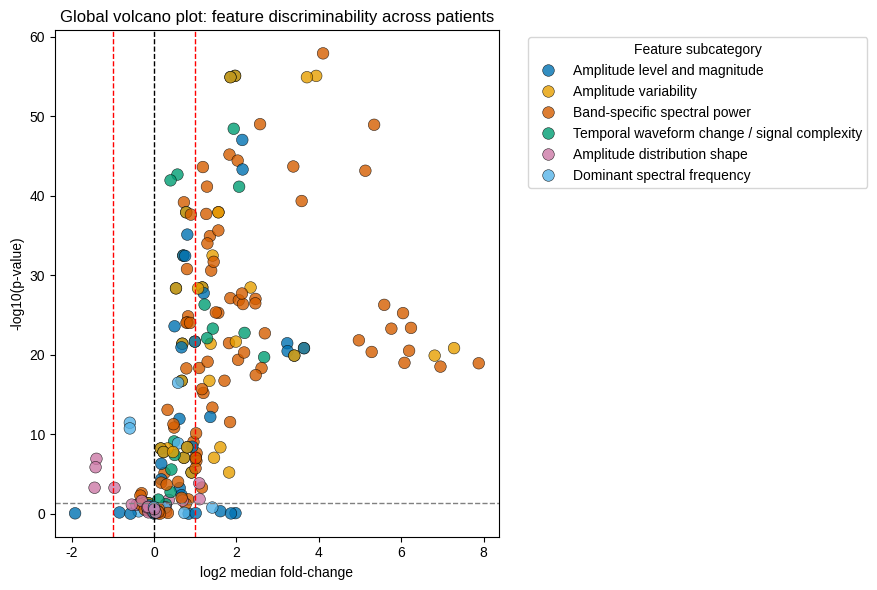

SVG saved in: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/src/test_and_develop/2_Feature_extraction/global_volcano_plot_2026-06-29.svg


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import date

alpha = 0.05

subcategory_palette = TEEG_FE.get_feature_subcategory_palette()

df_global_volcano = df_all_mannwhitney.query(
    "valid_log2_fold_change == True"
).copy()

# Output path: current notebook working directory + today's date
today = date.today().strftime("%Y-%m-%d")
output_path = Path.cwd() / f"global_volcano_plot_{today}.svg"

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_global_volcano,
    x="effect_size_log2_median_fold_change",
    y="neg_log10_p",
    hue="feature_subcategory",
    palette=subcategory_palette,
    s=70,
    edgecolor="black",
    linewidth=0.4,
    alpha=0.8
)

plt.axvline(0, linestyle="--", color="black", linewidth=1)

# Thresholds at log2FC = -1 and +1
plt.axvline(-1, linestyle="--", color="red", linewidth=1)
plt.axvline(1, linestyle="--", color="red", linewidth=1)

plt.axhline(-np.log10(alpha), linestyle="--", color="grey", linewidth=1)

plt.xlabel("log2 median fold-change")
plt.ylabel("-log10(p-value)")
plt.title("Global volcano plot: feature discriminability across patients")

plt.legend(
    title="Feature subcategory",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(output_path, format="svg", bbox_inches="tight")

plt.show()

print(f"SVG saved in: {output_path}")

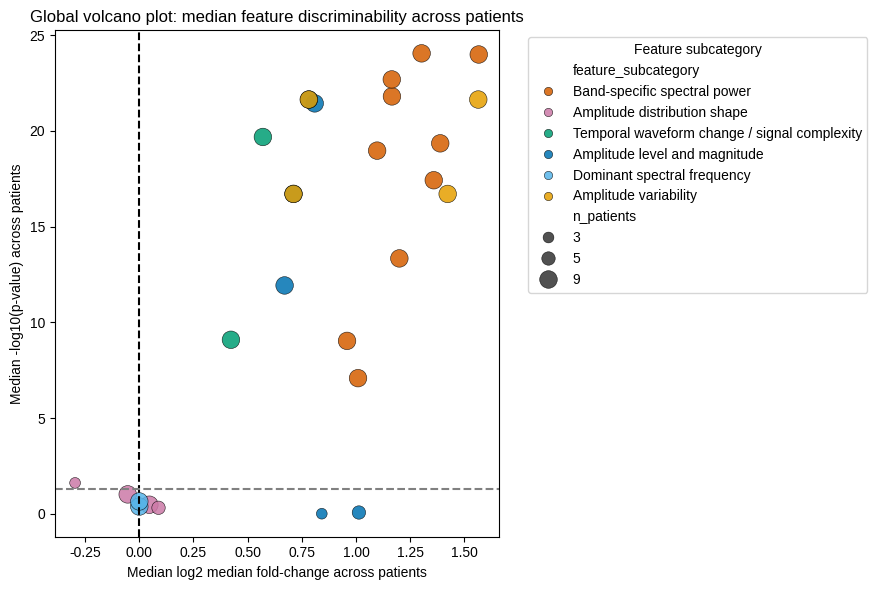

In [9]:
df_feature_global = (
    df_all_mannwhitney
    .query("valid_log2_fold_change == True")
    .groupby(["feature", "feature_subcategory", "feature_color"], as_index=False)
    .agg(
        median_log2_effect_size=("effect_size_log2_median_fold_change", "median"),
        median_neg_log10_p=("neg_log10_p", "median"),
        mean_neg_log10_p=("neg_log10_p", "mean"),
        n_patients=("patient_id", "nunique")
    )
)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_feature_global,
    x="median_log2_effect_size",
    y="median_neg_log10_p",
    hue="feature_subcategory",
    palette=subcategory_palette,
    size="n_patients",
    sizes=(60, 160),
    edgecolor="black",
    linewidth=0.4,
    alpha=0.85
)

plt.axvline(0, linestyle="--", color="black")
plt.axhline(-np.log10(alpha), linestyle="--", color="grey")

plt.xlabel("Median log2 median fold-change across patients")
plt.ylabel("Median -log10(p-value) across patients")
plt.title("Global volcano plot: median feature discriminability across patients")

plt.legend(
    title="Feature subcategory",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

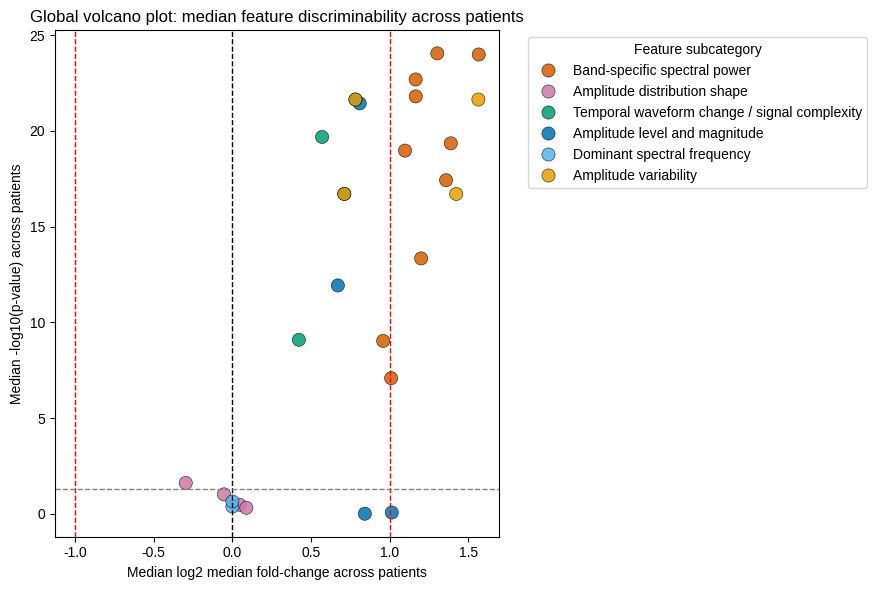

SVG saved in: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/src/test_and_develop/2_Feature_extraction/global_volcano_median_feature_discriminability_2026-06-29.svg


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import date

alpha = 0.05

subcategory_palette = TEEG_FE.get_feature_subcategory_palette()

df_feature_global = (
    df_all_mannwhitney
    .query("valid_log2_fold_change == True")
    .groupby(["feature", "feature_subcategory", "feature_color"], as_index=False)
    .agg(
        median_log2_effect_size=("effect_size_log2_median_fold_change", "median"),
        median_neg_log10_p=("neg_log10_p", "median"),
        mean_neg_log10_p=("neg_log10_p", "mean"),
        n_patients=("patient_id", "nunique")
    )
)

# Output path: current notebook working directory + today's date
today = date.today().strftime("%Y-%m-%d")
output_path = Path.cwd() / f"global_volcano_median_feature_discriminability_{today}.svg"

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_feature_global,
    x="median_log2_effect_size",
    y="median_neg_log10_p",
    hue="feature_subcategory",
    palette=subcategory_palette,
    s=90,
    edgecolor="black",
    linewidth=0.4,
    alpha=0.85
)

# Reference line at 0
plt.axvline(0, linestyle="--", color="black", linewidth=1)

# Thresholds at log2FC = -1 and +1
plt.axvline(-1, linestyle="--", color="red", linewidth=1)
plt.axvline(1, linestyle="--", color="red", linewidth=1)

# Significance threshold
plt.axhline(-np.log10(alpha), linestyle="--", color="grey", linewidth=1)

plt.xlabel("Median log2 median fold-change across patients")
plt.ylabel("Median -log10(p-value) across patients")
plt.title("Global volcano plot: median feature discriminability across patients")

plt.legend(
    title="Feature subcategory",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

# Save as SVG
plt.savefig(output_path, format="svg", bbox_inches="tight")

plt.show()

print(f"SVG saved in: {output_path}")

In [ ]:
## Barplots

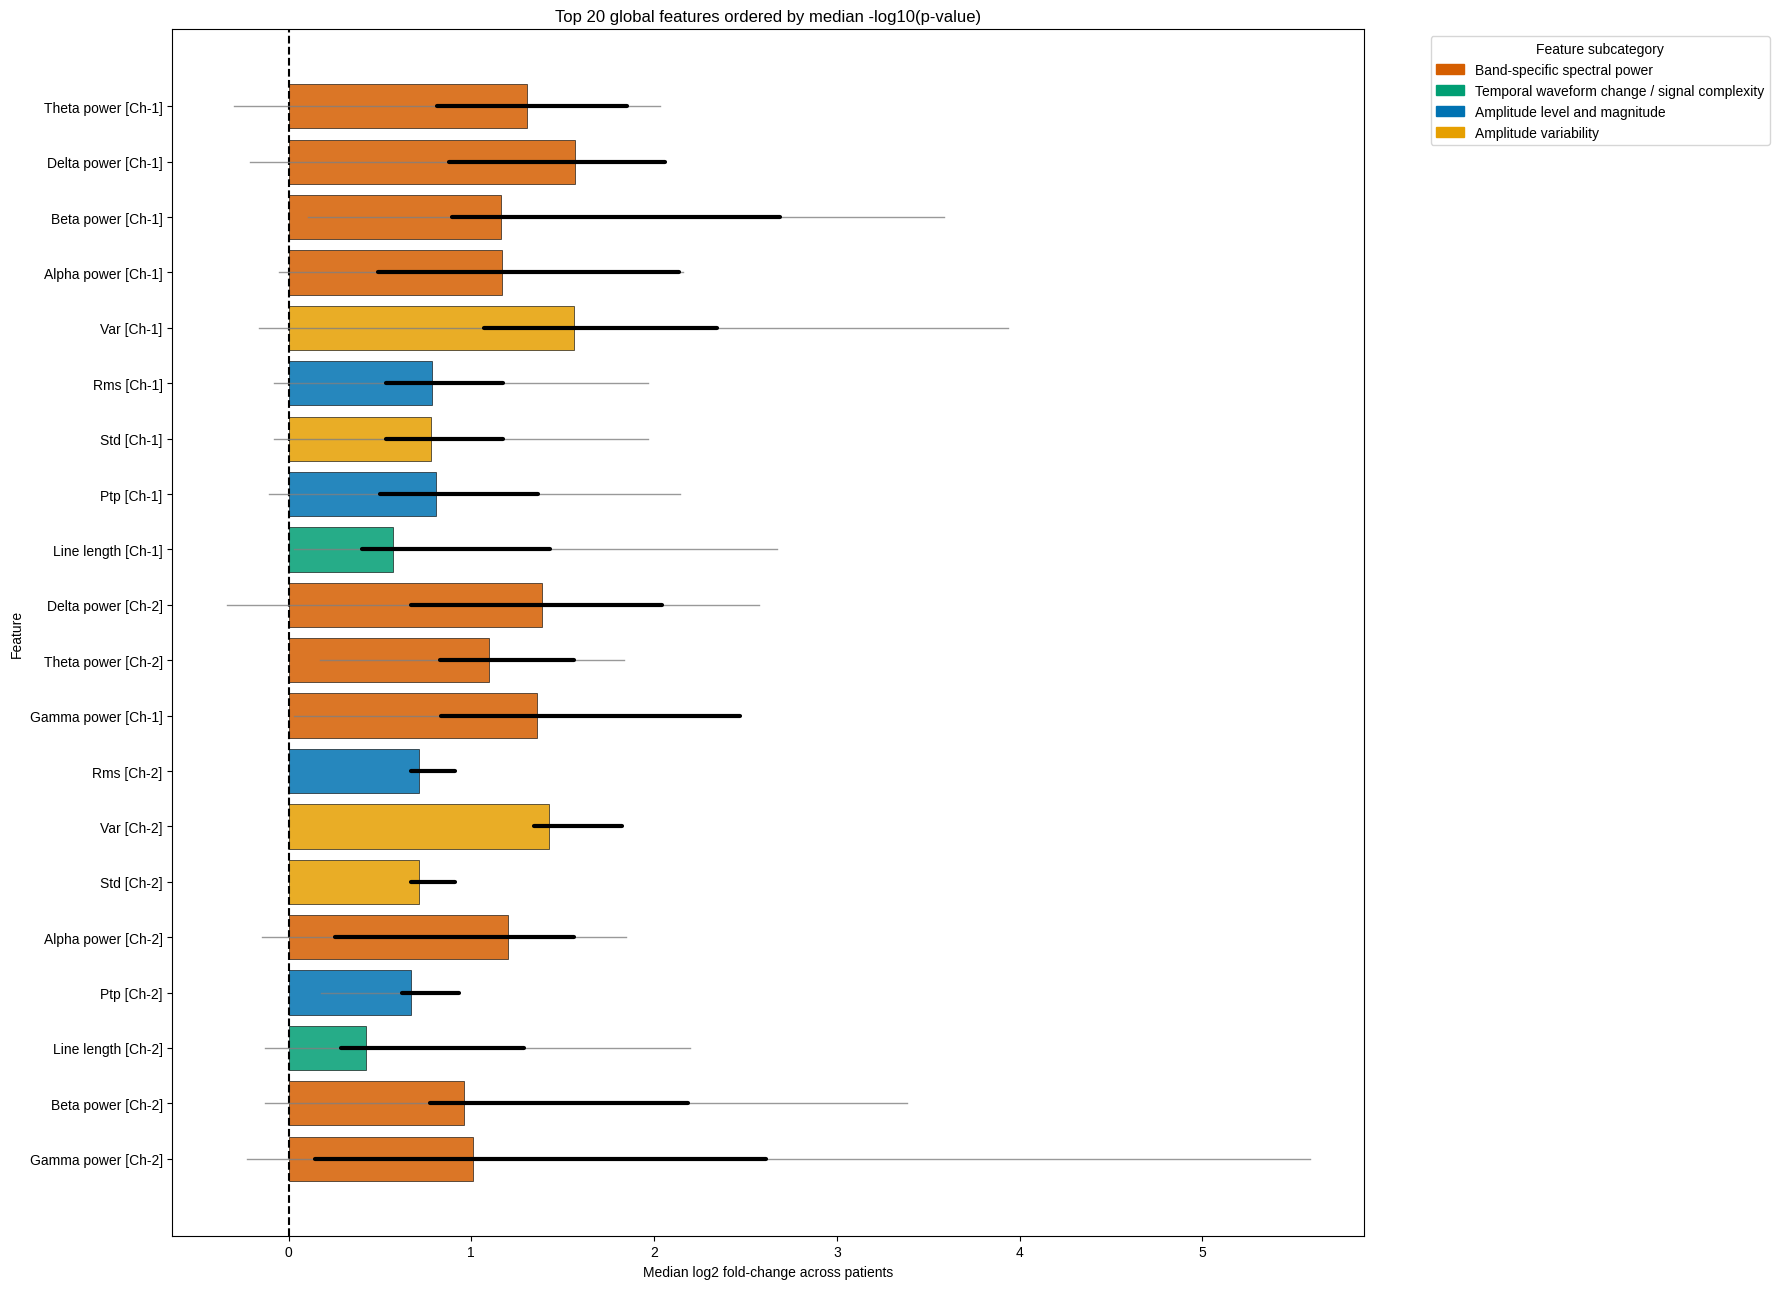

SVG saved in: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/src/test_and_develop/2_Feature_extraction/top_20_global_features_barplot_2026-06-29.svg


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import re
from pathlib import Path
from datetime import date


def format_feature_label_with_channel(feature):
    feature = str(feature)

    match = re.match(r"^(?P<base>.+?)_(?P<channel>EEG_.+)$", feature)

    if match:
        base = match.group("base")
        channel = match.group("channel")

        channel_map = {
            "EEG_SQ_P_SQ_C": "Ch-1",
            "EEG_SQ_D_SQ_C": "Ch-2"
        }

        channel_display = channel_map.get(channel, channel)
        base_display = base.replace("_", " ").capitalize()

        return f"{base_display} [{channel_display}]"

    return feature.replace("_", " ").capitalize()


top_n = 20

df_valid = (
    df_all_mannwhitney
    .query("valid_log2_fold_change == True")
    .copy()
)

# Summary statistics per feature
df_feature_summary = (
    df_valid
    .groupby(["feature", "feature_subcategory", "feature_color"], as_index=False)
    .agg(
        median_log2_effect_size=("effect_size_log2_median_fold_change", "median"),
        median_neg_log10_p=("neg_log10_p", "median"),
        q1_log2_effect_size=("effect_size_log2_median_fold_change", lambda x: x.quantile(0.25)),
        q3_log2_effect_size=("effect_size_log2_median_fold_change", lambda x: x.quantile(0.75)),
        n_patients=("patient_id", "nunique")
    )
)

# IQR and outlier thresholds
df_feature_summary["iqr"] = (
    df_feature_summary["q3_log2_effect_size"]
    - df_feature_summary["q1_log2_effect_size"]
)

df_feature_summary["lower_outlier_limit"] = (
    df_feature_summary["q1_log2_effect_size"]
    - 1.5 * df_feature_summary["iqr"]
)

df_feature_summary["upper_outlier_limit"] = (
    df_feature_summary["q3_log2_effect_size"]
    + 1.5 * df_feature_summary["iqr"]
)

# Select top N features by median significance
df_bar = (
    df_feature_summary
    .sort_values("median_neg_log10_p", ascending=False)
    .head(top_n)
    .copy()
)

df_bar["feature_display"] = (
    df_bar["feature"]
    .apply(format_feature_label_with_channel)
)

selected_features = df_bar["feature"].tolist()

# Merge thresholds back to patient-level values
df_selected_patient_values = (
    df_valid[df_valid["feature"].isin(selected_features)]
    .merge(
        df_bar[
            [
                "feature",
                "feature_display",
                "lower_outlier_limit",
                "upper_outlier_limit"
            ]
        ],
        on="feature",
        how="left"
    )
)

# Keep only inlier values
df_inliers = df_selected_patient_values[
    (
        df_selected_patient_values["effect_size_log2_median_fold_change"]
        >= df_selected_patient_values["lower_outlier_limit"]
    )
    &
    (
        df_selected_patient_values["effect_size_log2_median_fold_change"]
        <= df_selected_patient_values["upper_outlier_limit"]
    )
].copy()

# Compute whisker limits from inliers only
df_whiskers = (
    df_inliers
    .groupby("feature", as_index=False)
    .agg(
        whisker_min_log2_effect_size=("effect_size_log2_median_fold_change", "min"),
        whisker_max_log2_effect_size=("effect_size_log2_median_fold_change", "max")
    )
)

# Merge whiskers into plotting dataframe
df_bar = df_bar.merge(df_whiskers, on="feature", how="left")

# Order for plotting
df_bar = (
    df_bar
    .sort_values("median_neg_log10_p", ascending=True)
    .reset_index(drop=True)
)

# Output path
today = date.today().strftime("%Y-%m-%d")
output_path = Path.cwd() / f"top_{top_n}_global_features_barplot_{today}.svg"

# Plot
fig, ax = plt.subplots(figsize=(18, 0.55 * len(df_bar) + 2))
y_pos = np.arange(len(df_bar))

ax.barh(
    y=y_pos,
    width=df_bar["median_log2_effect_size"],
    color=df_bar["feature_color"],
    edgecolor="black",
    linewidth=0.5,
    alpha=0.85
)

# Grey whisker line = only non-outlier range
for i, row in df_bar.iterrows():
    ax.plot(
        [row["whisker_min_log2_effect_size"], row["whisker_max_log2_effect_size"]],
        [i, i],
        color="grey",
        linewidth=1,
        alpha=0.8,
        zorder=3
    )

    ax.plot(
        [row["q1_log2_effect_size"], row["q3_log2_effect_size"]],
        [i, i],
        color="black",
        linewidth=3,
        solid_capstyle="round",
        zorder=4
    )

ax.axvline(0, linestyle="--", color="black")

ax.set_yticks(y_pos)
ax.set_yticklabels(df_bar["feature_display"])

ax.set_xlabel("Median log2 fold-change across patients")
ax.set_ylabel("Feature")
ax.set_title(f"Top {top_n} global features ordered by median -log10(p-value)")

subcategory_palette = (
    df_bar
    .drop_duplicates("feature_subcategory")
    .set_index("feature_subcategory")["feature_color"]
    .to_dict()
)

legend_patches = [
    mpatches.Patch(color=color, label=subcategory)
    for subcategory, color in subcategory_palette.items()
]

ax.legend(
    handles=legend_patches,
    title="Feature subcategory",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

# Save as SVG
plt.savefig(output_path, format="svg", bbox_inches="tight")

plt.show()

print(f"SVG saved in: {output_path}")

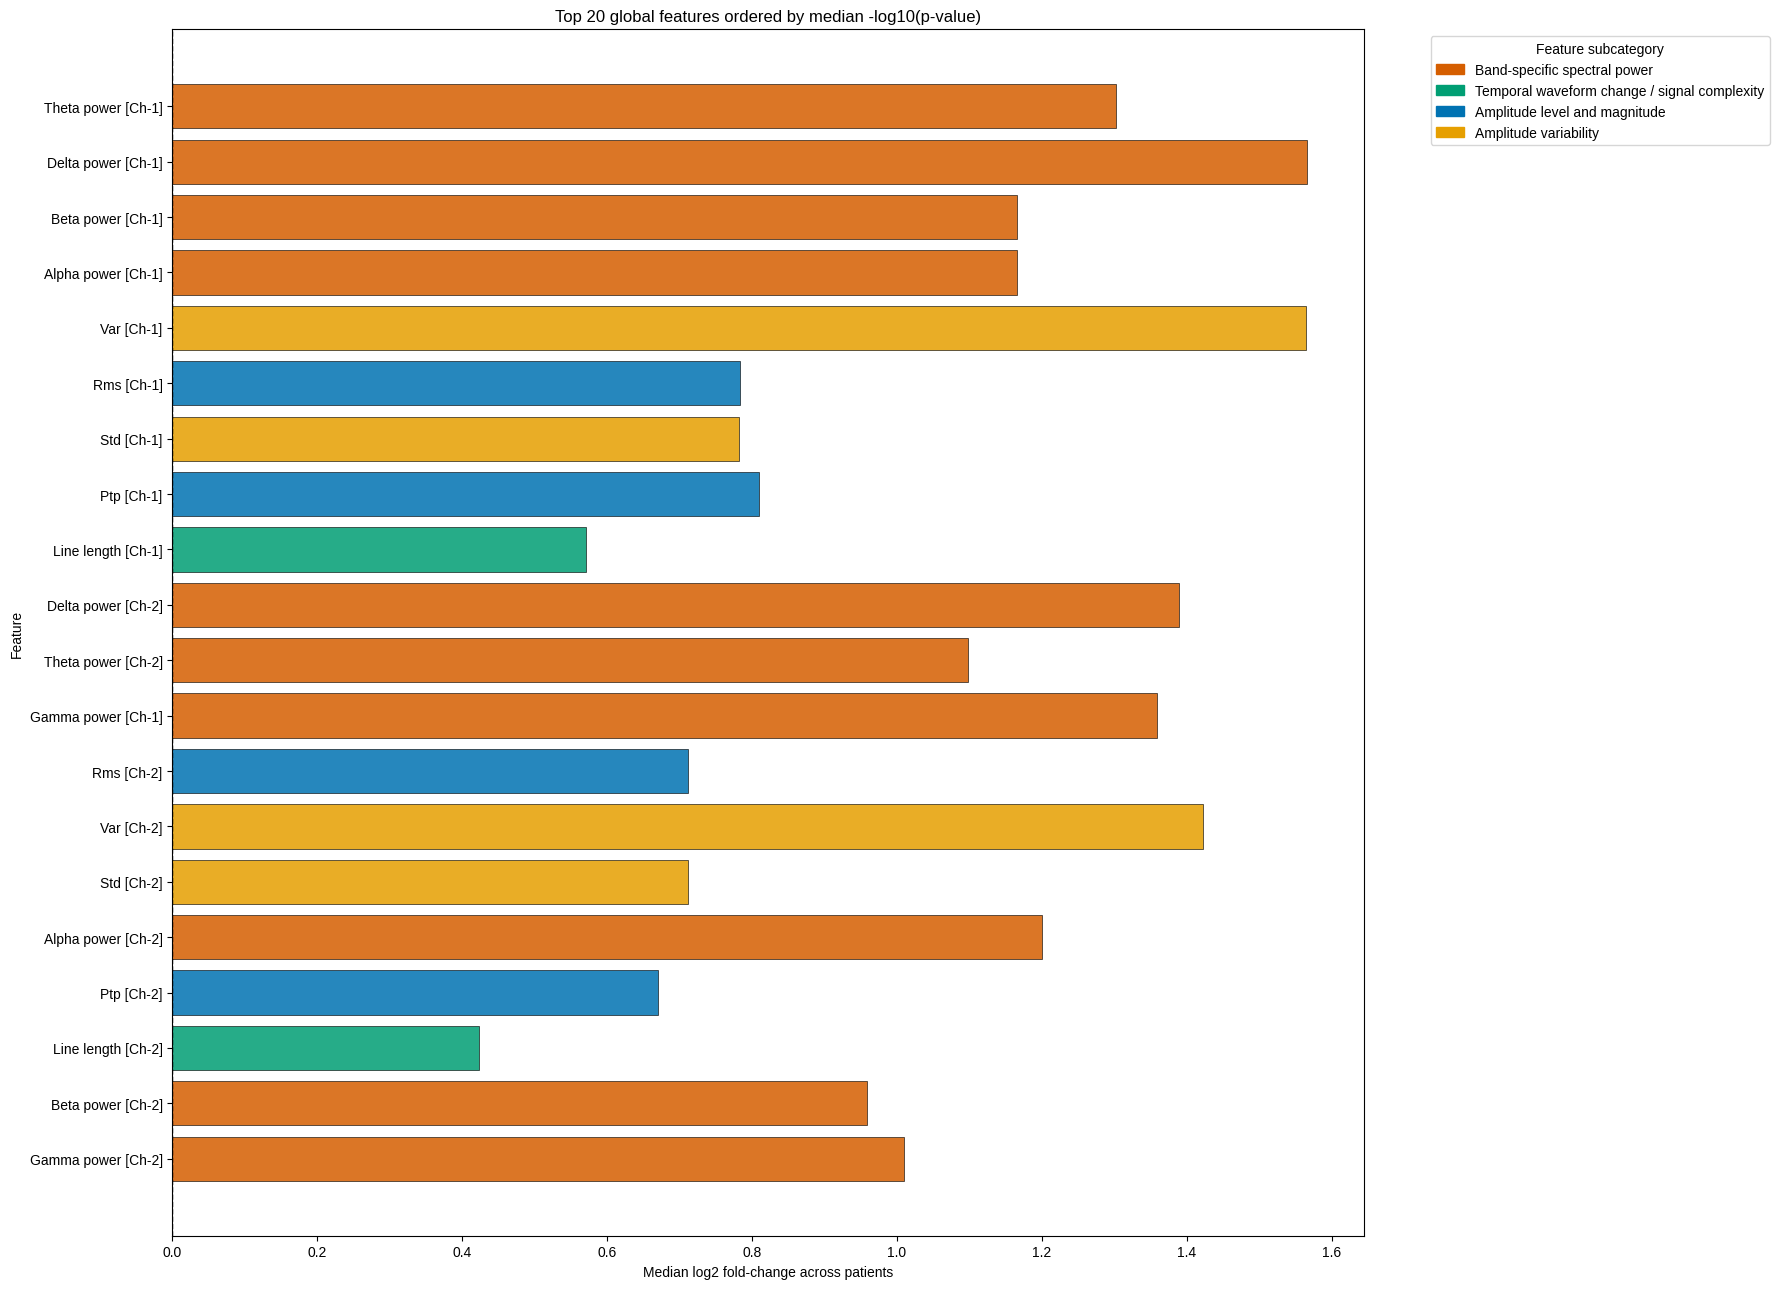

SVG saved in: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/src/test_and_develop/2_Feature_extraction/top_20_global_features_barplot_only_2026-06-29.svg


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import re
from pathlib import Path
from datetime import date


def format_feature_label_with_channel(feature):
    feature = str(feature)

    match = re.match(r"^(?P<base>.+?)_(?P<channel>EEG_.+)$", feature)

    if match:
        base = match.group("base")
        channel = match.group("channel")

        channel_map = {
            "EEG_SQ_P_SQ_C": "Ch-1",
            "EEG_SQ_D_SQ_C": "Ch-2"
        }

        channel_display = channel_map.get(channel, channel)
        base_display = base.replace("_", " ").capitalize()

        return f"{base_display} [{channel_display}]"

    return feature.replace("_", " ").capitalize()


top_n = 20

df_valid = (
    df_all_mannwhitney
    .query("valid_log2_fold_change == True")
    .copy()
)

df_feature_summary = (
    df_valid
    .groupby(["feature", "feature_subcategory", "feature_color"], as_index=False)
    .agg(
        median_log2_effect_size=("effect_size_log2_median_fold_change", "median"),
        median_neg_log10_p=("neg_log10_p", "median"),
        n_patients=("patient_id", "nunique")
    )
)

df_bar = (
    df_feature_summary
    .sort_values("median_neg_log10_p", ascending=False)
    .head(top_n)
    .copy()
)

df_bar["feature_display"] = (
    df_bar["feature"]
    .apply(format_feature_label_with_channel)
)

df_bar = (
    df_bar
    .sort_values("median_neg_log10_p", ascending=True)
    .reset_index(drop=True)
)

# Output path
today = date.today().strftime("%Y-%m-%d")
output_path = Path.cwd() / f"top_{top_n}_global_features_barplot_only_{today}.svg"

fig, ax = plt.subplots(figsize=(18, 0.55 * len(df_bar) + 2))

y_pos = np.arange(len(df_bar))

ax.barh(
    y=y_pos,
    width=df_bar["median_log2_effect_size"],
    color=df_bar["feature_color"],
    edgecolor="black",
    linewidth=0.5,
    alpha=0.85
)

ax.axvline(0, linestyle="--", color="black", linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(df_bar["feature_display"])

ax.set_xlabel("Median log2 fold-change across patients")
ax.set_ylabel("Feature")

ax.set_title(
    f"Top {top_n} global features ordered by median -log10(p-value)"
)

subcategory_palette = (
    df_bar
    .drop_duplicates("feature_subcategory")
    .set_index("feature_subcategory")["feature_color"]
    .to_dict()
)

legend_patches = [
    mpatches.Patch(color=color, label=subcategory)
    for subcategory, color in subcategory_palette.items()
]

ax.legend(
    handles=legend_patches,
    title="Feature subcategory",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(output_path, format="svg", bbox_inches="tight")

plt.show()

print(f"SVG saved in: {output_path}")

Using font: Liberation Sans


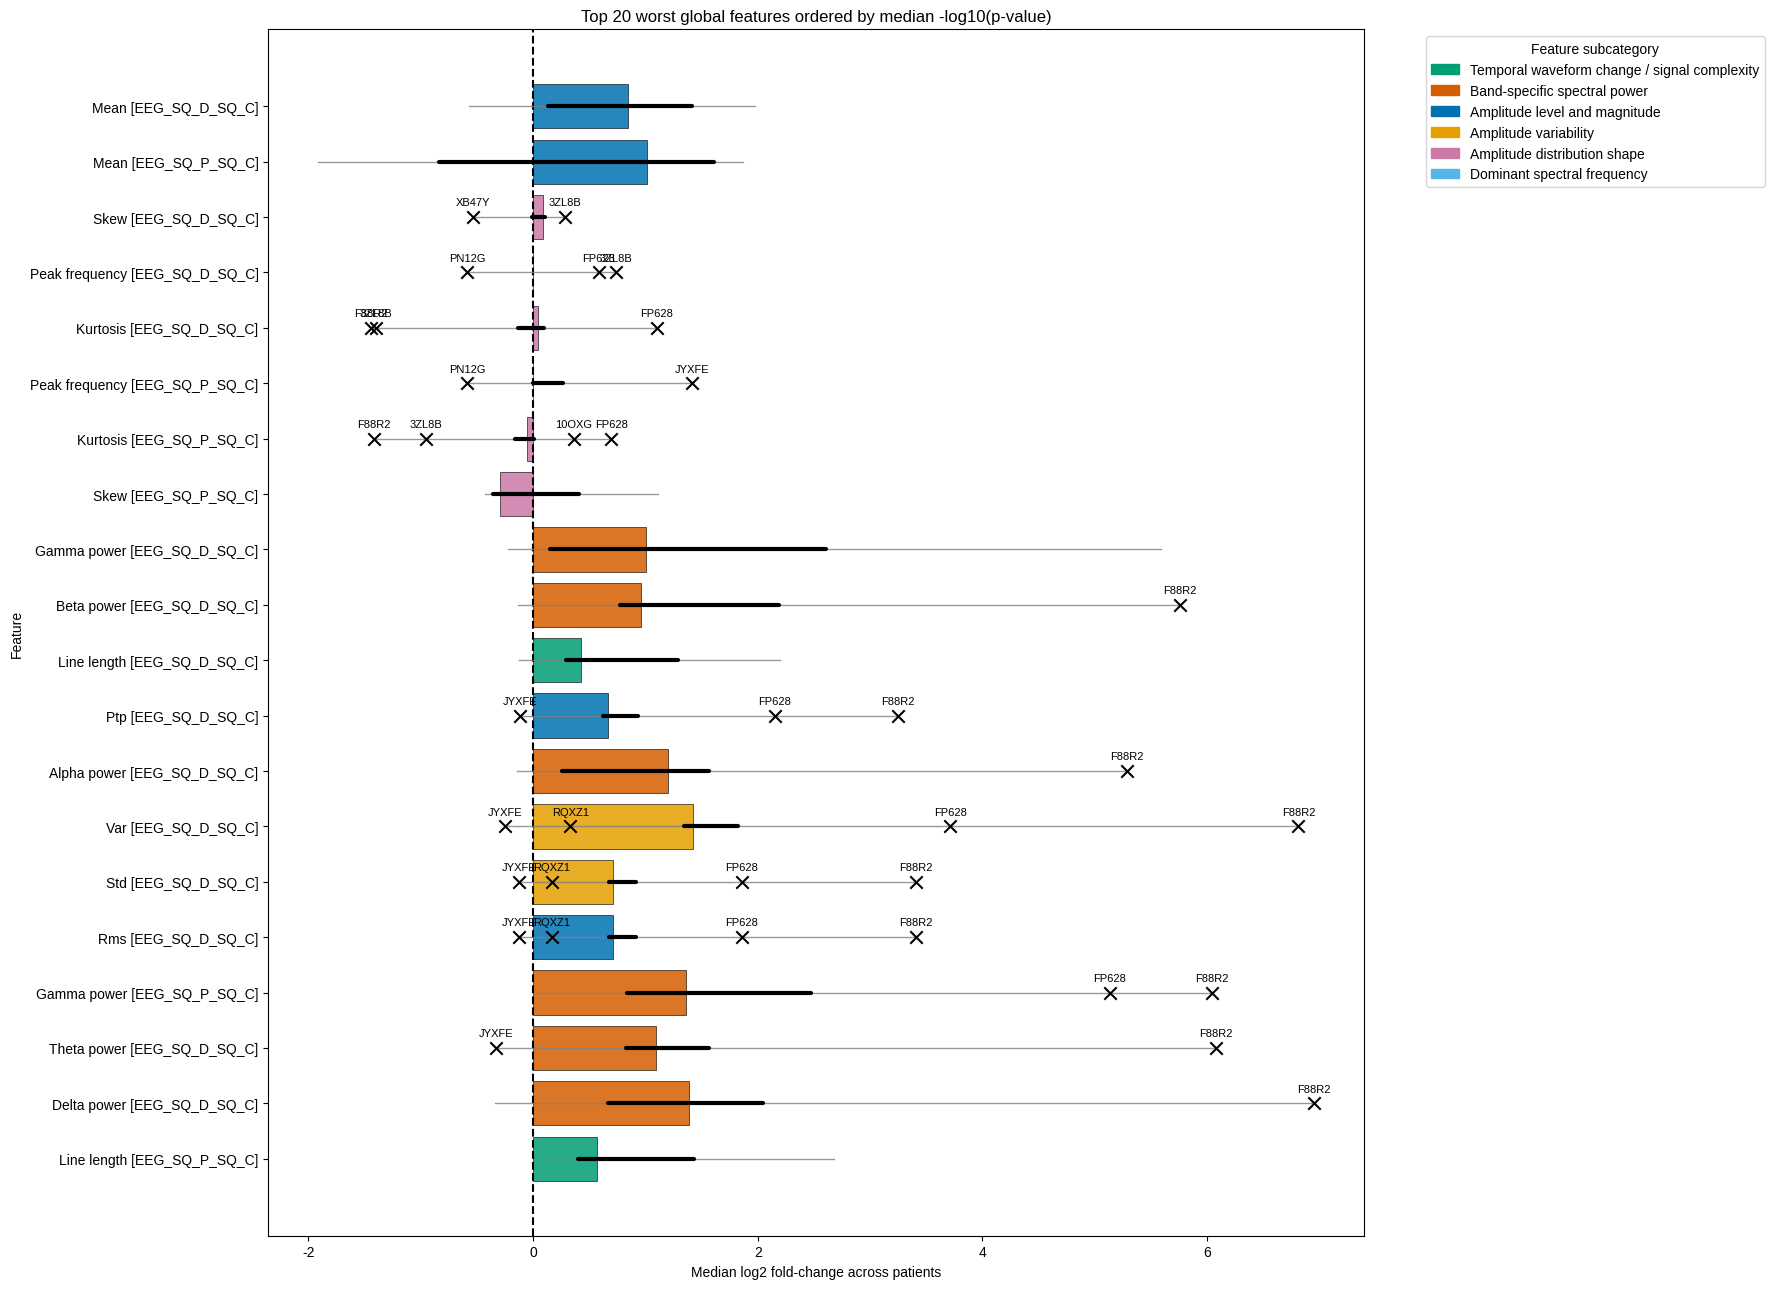

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import font_manager
import pandas as pd
import re


# ============================================================
# Font setup: Arial if available, otherwise fallback
# ============================================================

available_fonts = {f.name for f in font_manager.fontManager.ttflist}

if "Arial" in available_fonts:
    chosen_font = "Arial"
elif "Liberation Sans" in available_fonts:
    chosen_font = "Liberation Sans"
else:
    chosen_font = "DejaVu Sans"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": [chosen_font],
    "axes.unicode_minus": False
})

print(f"Using font: {chosen_font}")


# ============================================================
# Helper function
# ============================================================

def format_feature_label_with_channel(feature):
    feature = str(feature)

    match = re.match(r"^(?P<base>.+?)_(?P<channel>EEG_.+)$", feature)

    if match:
        base = match.group("base")
        channel = match.group("channel")
        base_display = base.replace("_", " ").capitalize()
        return f"{base_display} [{channel}]"

    return feature.replace("_", " ").capitalize()


# ============================================================
# Select worst global features
# ============================================================

top_n = 20

df_valid = (
    df_all_mannwhitney
    .query("valid_log2_fold_change == True")
    .copy()
)

df_feature_summary = (
    df_valid
    .groupby(["feature", "feature_subcategory", "feature_color"], as_index=False)
    .agg(
        median_log2_effect_size=("effect_size_log2_median_fold_change", "median"),
        median_neg_log10_p=("neg_log10_p", "median"),
        q1_log2_effect_size=("effect_size_log2_median_fold_change", lambda x: x.quantile(0.25)),
        q3_log2_effect_size=("effect_size_log2_median_fold_change", lambda x: x.quantile(0.75)),
        min_log2_effect_size=("effect_size_log2_median_fold_change", "min"),
        max_log2_effect_size=("effect_size_log2_median_fold_change", "max"),
        n_patients=("patient_id", "nunique")
    )
)

df_feature_summary["iqr"] = (
    df_feature_summary["q3_log2_effect_size"]
    - df_feature_summary["q1_log2_effect_size"]
)

df_feature_summary["lower_outlier_limit"] = (
    df_feature_summary["q1_log2_effect_size"]
    - 1.5 * df_feature_summary["iqr"]
)

df_feature_summary["upper_outlier_limit"] = (
    df_feature_summary["q3_log2_effect_size"]
    + 1.5 * df_feature_summary["iqr"]
)


# ============================================================
# Main difference: select lowest median -log10(p-value)
# ============================================================

df_bar = (
    df_feature_summary
    .sort_values("median_neg_log10_p", ascending=True)
    .head(top_n)
    .copy()
)

df_bar["feature_display"] = (
    df_bar["feature"]
    .apply(format_feature_label_with_channel)
)

# Reorder for plotting
# Highest among the worst at the top, lowest at the bottom
df_bar = (
    df_bar
    .sort_values("median_neg_log10_p", ascending=False)
    .reset_index(drop=True)
)

selected_features = df_bar["feature"].tolist()


# ============================================================
# Identify patient-level outliers
# ============================================================

df_selected_patient_values = (
    df_valid[df_valid["feature"].isin(selected_features)]
    .merge(
        df_bar[
            [
                "feature",
                "feature_display",
                "lower_outlier_limit",
                "upper_outlier_limit"
            ]
        ],
        on="feature",
        how="left"
    )
)

df_outliers = df_selected_patient_values[
    (
        df_selected_patient_values["effect_size_log2_median_fold_change"]
        < df_selected_patient_values["lower_outlier_limit"]
    )
    |
    (
        df_selected_patient_values["effect_size_log2_median_fold_change"]
        > df_selected_patient_values["upper_outlier_limit"]
    )
].copy()


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(18, 0.55 * len(df_bar) + 2))

y_pos = np.arange(len(df_bar))

ax.barh(
    y=y_pos,
    width=df_bar["median_log2_effect_size"],
    color=df_bar["feature_color"],
    edgecolor="black",
    linewidth=0.5,
    alpha=0.85
)

for i, row in df_bar.iterrows():
    ax.plot(
        [row["min_log2_effect_size"], row["max_log2_effect_size"]],
        [i, i],
        color="grey",
        linewidth=1,
        alpha=0.8,
        zorder=3
    )

    ax.plot(
        [row["q1_log2_effect_size"], row["q3_log2_effect_size"]],
        [i, i],
        color="black",
        linewidth=3,
        solid_capstyle="round",
        zorder=4
    )

for _, row in df_outliers.iterrows():
    y = df_bar.index[df_bar["feature"] == row["feature"]][0]
    x = row["effect_size_log2_median_fold_change"]

    ax.scatter(
        x,
        y,
        marker="x",
        s=80,
        color="black",
        linewidth=1.5,
        zorder=5
    )

    ax.annotate(
        str(row["patient_id"]),
        xy=(x, y),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
        color="black",
        zorder=6
    )

ax.axvline(0, linestyle="--", color="black")

ax.set_yticks(y_pos)
ax.set_yticklabels(df_bar["feature_display"])

ax.set_xlabel("Median log2 fold-change across patients")
ax.set_ylabel("Feature")

ax.set_title(
    f"Top {top_n} worst global features ordered by median -log10(p-value)"
)

subcategory_palette = (
    df_bar
    .drop_duplicates("feature_subcategory")
    .set_index("feature_subcategory")["feature_color"]
    .to_dict()
)

legend_patches = [
    mpatches.Patch(color=color, label=subcategory)
    for subcategory, color in subcategory_palette.items()
]

ax.legend(
    handles=legend_patches,
    title="Feature subcategory",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### DF top features:

In [10]:
import numpy as np
import pandas as pd

df_summary_input = df_all_mannwhitney.copy()

# -----------------------------
# 1. Define thresholds
# -----------------------------
if "alpha" in df_summary_input.columns:
    df_summary_input["alpha_used"] = df_summary_input["alpha"].fillna(0.05)
else:
    df_summary_input["alpha_used"] = 0.05

df_summary_input["is_significant"] = (
    df_summary_input["p_value"] < df_summary_input["alpha_used"]
)

df_summary_input["large_abs_effect"] = (
    df_summary_input["valid_log2_fold_change"].astype(bool)
    & (df_summary_input["abs_effect_size_log2_median_fold_change"] > 1)
)

df_summary_input["sig_and_large_effect"] = (
    df_summary_input["is_significant"]
    & df_summary_input["large_abs_effect"]
)

df_summary_input["ictal_higher"] = (
    df_summary_input["valid_log2_fold_change"].astype(bool)
    & (df_summary_input["effect_size_log2_median_fold_change"] > 0)
)

df_summary_input["neg_log10_p_clean"] = (
    df_summary_input["neg_log10_p"]
    .replace([np.inf, -np.inf], np.nan)
)


# -----------------------------
# 2. Patient-level summary
# -----------------------------
def summarise_patient(g):
    n_features = g["feature"].nunique()
    valid_effects = g[g["valid_log2_fold_change"].astype(bool)]

    top_idx = g["neg_log10_p_clean"].idxmax()
    top_row = g.loc[top_idx]

    return pd.Series({
        "n_features": n_features,

        "n_significant_features": g["is_significant"].sum(),
        "prop_significant_features": g["is_significant"].mean(),

        "n_large_effect_features": g["large_abs_effect"].sum(),
        "prop_large_effect_features": g["large_abs_effect"].mean(),

        "n_sig_and_large_effect": g["sig_and_large_effect"].sum(),
        "prop_sig_and_large_effect": g["sig_and_large_effect"].mean(),

        "min_neg_log10p": g["neg_log10_p_clean"].min(),
        "median_neg_log10p": g["neg_log10_p_clean"].median(),
        "max_neg_log10p": g["neg_log10_p_clean"].max(),

        "median_abs_effect_size": valid_effects["abs_effect_size_log2_median_fold_change"].median(),
        "max_abs_effect_size": valid_effects["abs_effect_size_log2_median_fold_change"].max(),

        "prop_ictal_higher": valid_effects["ictal_higher"].mean(),

        "top_feature": top_row["feature"],
        "top_feature_subcategory": top_row["feature_subcategory"],
        "top_feature_neg_log10p": top_row["neg_log10_p_clean"],
        "top_feature_log2FC": top_row["effect_size_log2_median_fold_change"],
    })


patient_feature_summary = (
    df_summary_input
    .groupby("patient_id")
    .apply(summarise_patient)
    .reset_index()
)

patient_feature_summary

/tmp/ipykernel_49358/910527278.py:80: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarise_patient)


,patient_id,n_features,n_significant_features,prop_significant_features,n_large_effect_features,prop_large_effect_features,n_sig_and_large_effect,prop_sig_and_large_effect,min_neg_log10p,median_neg_log10p,max_neg_log10p,median_abs_effect_size,max_abs_effect_size,prop_ictal_higher,top_feature,top_feature_subcategory,top_feature_neg_log10p,top_feature_log2FC
0,10OXG,28,23,0.821429,15,0.535714,15,0.535714,0.008435,16.710027,28.453410,1.135059,2.463589,0.846154,rms_EEG_SQ_P_SQ_C,Amplitude level and magnitude,28.453410,1.172756
1,1JSZ6,28,20,0.714286,5,0.178571,5,0.178571,0.004282,31.590753,42.646132,0.756815,1.566253,0.851852,line_length_EEG_SQ_P_SQ_C,Temporal waveform change / signal complexity,42.646132,0.570247
2,3ZL8B,28,19,0.678571,10,0.357143,10,0.357143,0.020983,3.273522,25.254681,0.911937,2.042183,0.880000,theta_power_EEG_SQ_D_SQ_C,Band-specific spectral power,25.254681,1.561722
3,F88R2,28,22,0.785714,23,0.821429,22,0.785714,0.040057,19.878645,26.264056,3.641525,7.882350,0.840000,gamma_power_EEG_SQ_D_SQ_C,Band-specific spectral power,26.264056,5.588542
4,FP628,28,25,0.892857,22,0.785714,21,0.750000,0.077955,43.474753,57.887503,1.978783,5.343154,1.000000,delta_power_EEG_SQ_P_SQ_C,Band-specific spectral power,57.887503,4.104048
5,JYXFE,28,6,0.214286,2,0.071429,0,0.000000,0.011772,0.577308,2.584286,0.131617,1.415037,0.230769,theta_power_EEG_SQ_P_SQ_C,Band-specific spectral power,2.584286,-0.298634
6,PN12G,28,23,0.821429,11,0.392857,10,0.357143,0.041799,14.858997,43.592151,0.737384,1.869182,0.807692,theta_power_EEG_SQ_D_SQ_C,Band-specific spectral power,43.592151,1.188415
7,RQXZ1,28,15,0.535714,0,0.000000,0,0.000000,0.065780,1.922818,23.993737,0.164997,0.878104,0.880000,delta_power_EEG_SQ_P_SQ_C,Band-specific spectral power,23.993737,0.878104
8,XB47Y,28,22,0.785714,15,0.535714,14,0.500000,0.001926,9.974021,27.690075,1.107300,2.691579,0.851852,alpha_power_EEG_SQ_P_SQ_C,Band-specific spectral power,27.690075,2.136140


In [11]:
patient_feature_summary_table = patient_feature_summary.copy()

percentage_cols = [
    "prop_significant_features",
    "prop_large_effect_features",
    "prop_sig_and_large_effect",
    "prop_ictal_higher"
]

for col in percentage_cols:
    patient_feature_summary_table[col] = (
        patient_feature_summary_table[col] * 100
    ).round(1)

round_cols = [
    "min_neg_log10p",
    "median_neg_log10p",
    "max_neg_log10p",
    "median_abs_effect_size",
    "max_abs_effect_size",
    "top_feature_neg_log10p",
    "top_feature_log2FC"
]

for col in round_cols:
    patient_feature_summary_table[col] = patient_feature_summary_table[col].round(2)

patient_feature_summary_table["neg_log10p_range"] = (
    patient_feature_summary_table["min_neg_log10p"].astype(str)
    + "–"
    + patient_feature_summary_table["max_neg_log10p"].astype(str)
)

cols_for_thesis = [
    "patient_id",
    "n_features",
    "prop_significant_features",
    "prop_large_effect_features",
    "prop_sig_and_large_effect",
    "neg_log10p_range",
    "median_abs_effect_size",
    "prop_ictal_higher",
    "top_feature_subcategory",
    "top_feature"
]


thesis_table = patient_feature_summary_table[cols_for_thesis]

# Save table as CSV
csv_output_path = "patient_feature_summary_table.csv"
thesis_table.to_csv(csv_output_path, index=False)

thesis_table

,patient_id,n_features,prop_significant_features,prop_large_effect_features,prop_sig_and_large_effect,neg_log10p_range,median_abs_effect_size,prop_ictal_higher,top_feature_subcategory,top_feature
0,10OXG,28,82.1,53.6,53.6,0.01–28.45,1.14,84.6,Amplitude level and magnitude,rms_EEG_SQ_P_SQ_C
1,1JSZ6,28,71.4,17.9,17.9,0.0–42.65,0.76,85.2,Temporal waveform change / signal complexity,line_length_EEG_SQ_P_SQ_C
2,3ZL8B,28,67.9,35.7,35.7,0.02–25.25,0.91,88.0,Band-specific spectral power,theta_power_EEG_SQ_D_SQ_C
3,F88R2,28,78.6,82.1,78.6,0.04–26.26,3.64,84.0,Band-specific spectral power,gamma_power_EEG_SQ_D_SQ_C
4,FP628,28,89.3,78.6,75.0,0.08–57.89,1.98,100.0,Band-specific spectral power,delta_power_EEG_SQ_P_SQ_C
5,JYXFE,28,21.4,7.1,0.0,0.01–2.58,0.13,23.1,Band-specific spectral power,theta_power_EEG_SQ_P_SQ_C
6,PN12G,28,82.1,39.3,35.7,0.04–43.59,0.74,80.8,Band-specific spectral power,theta_power_EEG_SQ_D_SQ_C
7,RQXZ1,28,53.6,0.0,0.0,0.07–23.99,0.16,88.0,Band-specific spectral power,delta_power_EEG_SQ_P_SQ_C
8,XB47Y,28,78.6,53.6,50.0,0.0–27.69,1.11,85.2,Band-specific spectral power,alpha_power_EEG_SQ_P_SQ_C


In [12]:
import numpy as np
import pandas as pd

df_summary_input = df_all_mannwhitney.copy()

# -----------------------------
# 1. Define thresholds
# -----------------------------
if "alpha" in df_summary_input.columns:
    df_summary_input["alpha_used"] = df_summary_input["alpha"].fillna(0.05)
else:
    df_summary_input["alpha_used"] = 0.05

df_summary_input["is_significant"] = (
    df_summary_input["p_value"] < df_summary_input["alpha_used"]
)

df_summary_input["large_abs_effect"] = (
    df_summary_input["valid_log2_fold_change"].astype(bool)
    & (df_summary_input["abs_effect_size_log2_median_fold_change"] > 1)
)

df_summary_input["sig_and_large_effect"] = (
    df_summary_input["is_significant"]
    & df_summary_input["large_abs_effect"]
)

df_summary_input["ictal_higher"] = (
    df_summary_input["valid_log2_fold_change"].astype(bool)
    & (df_summary_input["effect_size_log2_median_fold_change"] > 0)
)

df_summary_input["neg_log10_p_clean"] = (
    df_summary_input["neg_log10_p"]
    .replace([np.inf, -np.inf], np.nan)
)


# -----------------------------
# 2. Patient-level summary with worst feature
# -----------------------------
def summarise_patient_worst(g):
    n_features = g["feature"].nunique()
    valid_effects = g[g["valid_log2_fold_change"].astype(bool)]

    # Worst feature = lowest statistical evidence
    worst_idx = g["neg_log10_p_clean"].idxmin()
    worst_row = g.loc[worst_idx]

    return pd.Series({
        "n_features": n_features,

        "n_significant_features": g["is_significant"].sum(),
        "prop_significant_features": g["is_significant"].mean(),

        "n_large_effect_features": g["large_abs_effect"].sum(),
        "prop_large_effect_features": g["large_abs_effect"].mean(),

        "n_sig_and_large_effect": g["sig_and_large_effect"].sum(),
        "prop_sig_and_large_effect": g["sig_and_large_effect"].mean(),

        "min_neg_log10p": g["neg_log10_p_clean"].min(),
        "median_neg_log10p": g["neg_log10_p_clean"].median(),
        "max_neg_log10p": g["neg_log10_p_clean"].max(),

        "median_abs_effect_size": valid_effects["abs_effect_size_log2_median_fold_change"].median(),
        "max_abs_effect_size": valid_effects["abs_effect_size_log2_median_fold_change"].max(),

        "prop_ictal_higher": valid_effects["ictal_higher"].mean(),

        "worst_feature": worst_row["feature"],
        "worst_feature_subcategory": worst_row["feature_subcategory"],
        "worst_feature_neg_log10p": worst_row["neg_log10_p_clean"],
        "worst_feature_log2FC": worst_row["effect_size_log2_median_fold_change"],
        "worst_feature_abs_log2FC": worst_row["abs_effect_size_log2_median_fold_change"],
        "worst_feature_p_value": worst_row["p_value"],
    })


patient_worst_feature_summary = (
    df_summary_input
    .groupby("patient_id")
    .apply(summarise_patient_worst)
    .reset_index()
)
patient_worst_feature_summary_table = patient_worst_feature_summary.copy()

percentage_cols = [
    "prop_significant_features",
    "prop_large_effect_features",
    "prop_sig_and_large_effect",
    "prop_ictal_higher"
]

for col in percentage_cols:
    patient_worst_feature_summary_table[col] = (
        patient_worst_feature_summary_table[col] * 100
    ).round(1)

round_cols = [
    "min_neg_log10p",
    "median_neg_log10p",
    "max_neg_log10p",
    "median_abs_effect_size",
    "max_abs_effect_size",
    "worst_feature_neg_log10p",
    "worst_feature_log2FC",
    "worst_feature_abs_log2FC",
    "worst_feature_p_value"
]

for col in round_cols:
    patient_worst_feature_summary_table[col] = (
        patient_worst_feature_summary_table[col].round(3)
    )

patient_worst_feature_summary_table["neg_log10p_range"] = (
    patient_worst_feature_summary_table["min_neg_log10p"].astype(str)
    + "–"
    + patient_worst_feature_summary_table["max_neg_log10p"].astype(str)
)

cols_for_thesis_worst = [
    "patient_id",
    "n_features",
    "prop_significant_features",
    "prop_large_effect_features",
    "prop_sig_and_large_effect",
    "neg_log10p_range",
    "median_abs_effect_size",
    "prop_ictal_higher",
    "worst_feature_subcategory",
    "worst_feature",
    "worst_feature_neg_log10p",
    "worst_feature_log2FC"
]

thesis_worst_table = patient_worst_feature_summary_table[cols_for_thesis_worst]

thesis_worst_table

/tmp/ipykernel_49358/1721156951.py:83: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarise_patient_worst)


,patient_id,n_features,prop_significant_features,prop_large_effect_features,prop_sig_and_large_effect,neg_log10p_range,median_abs_effect_size,prop_ictal_higher,worst_feature_subcategory,worst_feature,worst_feature_neg_log10p,worst_feature_log2FC
0,10OXG,28,82.1,53.6,53.6,0.008–28.453,1.135,84.6,Amplitude level and magnitude,mean_EEG_SQ_D_SQ_C,0.008,-0.570
1,1JSZ6,28,71.4,17.9,17.9,0.004–42.646,0.757,85.2,Amplitude level and magnitude,mean_EEG_SQ_D_SQ_C,0.004,0.842
2,3ZL8B,28,67.9,35.7,35.7,0.021–25.255,0.912,88.0,Amplitude level and magnitude,mean_EEG_SQ_D_SQ_C,0.021,NaN
3,F88R2,28,78.6,82.1,78.6,0.04–26.264,3.642,84.0,Dominant spectral frequency,peak_frequency_EEG_SQ_P_SQ_C,0.040,0.000
4,FP628,28,89.3,78.6,75.0,0.078–57.888,1.979,100.0,Amplitude level and magnitude,mean_EEG_SQ_D_SQ_C,0.078,1.979
5,JYXFE,28,21.4,7.1,0.0,0.012–2.584,0.132,23.1,Band-specific spectral power,beta_power_EEG_SQ_P_SQ_C,0.012,0.147
6,PN12G,28,82.1,39.3,35.7,0.042–43.592,0.737,80.8,Amplitude level and magnitude,mean_EEG_SQ_P_SQ_C,0.042,1.869
7,RQXZ1,28,53.6,0.0,0.0,0.066–23.994,0.165,88.0,Amplitude level and magnitude,mean_EEG_SQ_D_SQ_C,0.066,NaN
8,XB47Y,28,78.6,53.6,50.0,0.002–27.69,1.107,85.2,Amplitude level and magnitude,mean_EEG_SQ_D_SQ_C,0.002,NaN


# DF: results

In [13]:
import pandas as pd
from io import StringIO

# ============================================================
# 1. Dataset characteristics dataframe
# ============================================================

data_characteristics = """Patient ID	sqEEG recorded (h)	Seizures, n	Recording duration, days	Seizure density	Date capture rate
10OXG	6,943	56	506	0.19	13.7, 57.2%
1JSZ6	9,472	63	417	0.16	22.8, 95.0%
3ZL8B	11,692	54	538	0.11	21.7, 90.5%
F88R2	4,941	33	241	0.16	20.5, 85.4%
FP628	9,319	92	495	0.24	18.8, 78.4%
JYXFE	3,620	31	433	0.21	8.4, 34.8%
PN12G	10,363	132	438	0.31	23.7, 98.6%
RQXZ1	2,783	203	263	1.75	10.6, 44.1%
XB47Y	809	36	45	1.07	17.9, 74.7%
"""

df_characteristics = pd.read_csv(StringIO(data_characteristics), sep="\t")

# Clean numeric columns
df_characteristics["sqEEG recorded (h)"] = (
    df_characteristics["sqEEG recorded (h)"]
    .str.replace(",", "", regex=False)
    .astype(int)
)

# Split data capture rate into two separate columns
df_characteristics[["Data capture rate, h/day", "Data capture rate, %"]] = (
    df_characteristics["Date capture rate"]
    .str.extract(r"([\d.]+),\s*([\d.]+)%")
    .astype(float)
)

df_characteristics = df_characteristics.drop(columns=["Date capture rate"])

df_characteristics

,Patient ID,sqEEG recorded (h),"Seizures, n","Recording duration, days",Seizure density,"Data capture rate, h/day","Data capture rate, %"
0,10OXG,6943,56,506,0.19,13.7,57.2
1,1JSZ6,9472,63,417,0.16,22.8,95.0
2,3ZL8B,11692,54,538,0.11,21.7,90.5
3,F88R2,4941,33,241,0.16,20.5,85.4
4,FP628,9319,92,495,0.24,18.8,78.4
5,JYXFE,3620,31,433,0.21,8.4,34.8
6,PN12G,10363,132,438,0.31,23.7,98.6
7,RQXZ1,2783,203,263,1.75,10.6,44.1
8,XB47Y,809,36,45,1.07,17.9,74.7


In [14]:
# ============================================================
# 2. Model performance dataframe
# ============================================================

data_performance = """Patient ID	Best by accuracy	Best accuracy	Best by weighted F1	Weighted F1	Preictal F1	Ictal F1	Same best model?
10OXG	FEAT. + SVM	0.811	FEAT. + SVM	0.811	0.807	0.814	Yes
1JSZ6	PCA + RF	0.878	PCA + RF	0.877	0.860	0.892	Yes
3ZL8B	FEAT. + SVM	0.750	FEAT.+ SVM	0.749	0.767	0.731	Yes
F88R2	PCA + RF	0.897	PCA + RF	0.897	0.901	0.892	Yes
FP628	FEAT. + SVM	0.876	FEAT. + SVM	0.876	0.861	0.889	Yes
JYXFE	PCA + SVM	0.382	FEAT. + SVM	0.306	0.345	0.269	No
PN12G	FEAT. + SVM	0.739	FEAT. + SVM	0.739	0.746	0.732	Yes
RQXZ1	PCA + SVM	0.537	PCA + DT	0.514	0.533	0.496	No
XB47Y	PCA + RF	0.644	PCA + RF	0.641	0.658	0.629	Yes
"""

df_performance = pd.read_csv(StringIO(data_performance), sep="\t")

# Optional: clean small formatting inconsistency
df_performance["Best by weighted F1"] = (
    df_performance["Best by weighted F1"]
    .str.replace("FEAT.+", "FEAT. +", regex=False)
)

df_performance

,Patient ID,Best by accuracy,Best accuracy,Best by weighted F1,Weighted F1,Preictal F1,Ictal F1,Same best model?
0,10OXG,FEAT. + SVM,0.811,FEAT. + SVM,0.811,0.807,0.814,Yes
1,1JSZ6,PCA + RF,0.878,PCA + RF,0.877,0.860,0.892,Yes
2,3ZL8B,FEAT. + SVM,0.750,FEAT. + SVM,0.749,0.767,0.731,Yes
3,F88R2,PCA + RF,0.897,PCA + RF,0.897,0.901,0.892,Yes
4,FP628,FEAT. + SVM,0.876,FEAT. + SVM,0.876,0.861,0.889,Yes
5,JYXFE,PCA + SVM,0.382,FEAT. + SVM,0.306,0.345,0.269,No
6,PN12G,FEAT. + SVM,0.739,FEAT. + SVM,0.739,0.746,0.732,Yes
7,RQXZ1,PCA + SVM,0.537,PCA + DT,0.514,0.533,0.496,No
8,XB47Y,PCA + RF,0.644,PCA + RF,0.641,0.658,0.629,Yes


In [15]:
# ============================================================
# 3. Merge both dataframes
# ============================================================

df_merged = pd.merge(
    df_characteristics,
    df_performance,
    on="Patient ID",
    how="inner"
)

df_merged

,Patient ID,sqEEG recorded (h),"Seizures, n","Recording duration, days",Seizure density,"Data capture rate, h/day","Data capture rate, %",Best by accuracy,Best accuracy,Best by weighted F1,Weighted F1,Preictal F1,Ictal F1,Same best model?
0,10OXG,6943,56,506,0.19,13.7,57.2,FEAT. + SVM,0.811,FEAT. + SVM,0.811,0.807,0.814,Yes
1,1JSZ6,9472,63,417,0.16,22.8,95.0,PCA + RF,0.878,PCA + RF,0.877,0.860,0.892,Yes
2,3ZL8B,11692,54,538,0.11,21.7,90.5,FEAT. + SVM,0.750,FEAT. + SVM,0.749,0.767,0.731,Yes
3,F88R2,4941,33,241,0.16,20.5,85.4,PCA + RF,0.897,PCA + RF,0.897,0.901,0.892,Yes
4,FP628,9319,92,495,0.24,18.8,78.4,FEAT. + SVM,0.876,FEAT. + SVM,0.876,0.861,0.889,Yes
5,JYXFE,3620,31,433,0.21,8.4,34.8,PCA + SVM,0.382,FEAT. + SVM,0.306,0.345,0.269,No
6,PN12G,10363,132,438,0.31,23.7,98.6,FEAT. + SVM,0.739,FEAT. + SVM,0.739,0.746,0.732,Yes
7,RQXZ1,2783,203,263,1.75,10.6,44.1,PCA + SVM,0.537,PCA + DT,0.514,0.533,0.496,No
8,XB47Y,809,36,45,1.07,17.9,74.7,PCA + RF,0.644,PCA + RF,0.641,0.658,0.629,Yes


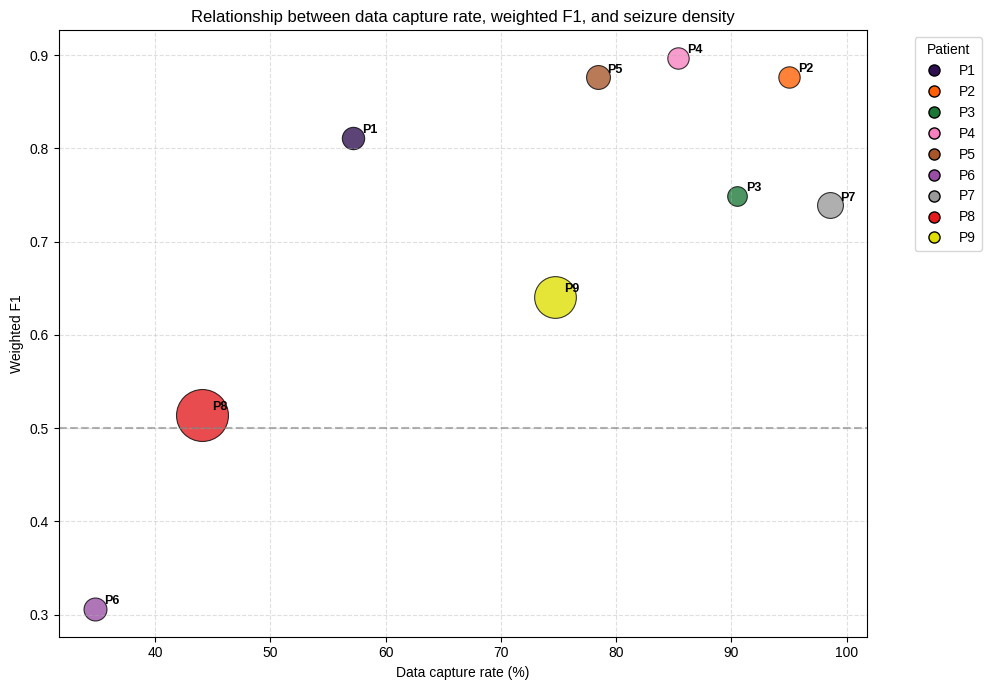

SVG saved in: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/src/test_and_develop/2_Feature_extraction/bubble_data_capture_weighted_f1_seizure_density_CB_palette_2026-06-29.svg


In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from pathlib import Path
from datetime import date

# ============================================================
# Bubble scatter plot
# X = Data capture rate (%)
# Y = Weighted F1
# Bubble size = Seizure density
# Colour = Patient number
# Label = Patient number
# ============================================================

patient_number_map = {
    "10OXG": "P1",
    "1JSZ6": "P2",
    "3ZL8B": "P3",
    "F88R2": "P4",
    "FP628": "P5",
    "JYXFE": "P6",
    "PN12G": "P7",
    "RQXZ1": "P8",
    "XB47Y": "P9"
}

patient_order = ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8", "P9"]

df_plot = df_merged.copy()

# Replace original patient IDs with assigned patient numbers
df_plot["Patient"] = df_plot["Patient ID"].map(patient_number_map)

# Optional check: identify unmapped patients
unmapped_patients = df_plot.loc[df_plot["Patient"].isna(), "Patient ID"].unique()
if len(unmapped_patients) > 0:
    print("Warning: these Patient IDs were not mapped:", unmapped_patients)

# Sort by assigned patient number
df_plot["Patient"] = pd.Categorical(
    df_plot["Patient"],
    categories=patient_order,
    ordered=True
)

df_plot = df_plot.sort_values("Patient")

CB_color_cycle = [
    '#2E0F4F',  # P1 - very dark violet
    '#FF5F00',  # P2 - very bright orange
    '#1B7837',  # P3 - dark green
    '#f781bf',  # P4 - pink
    '#a65628',  # P5 - brown
    '#984ea3',  # P6 - purple
    '#999999',  # P7 - grey
    '#e41a1c',  # P8 - red
    '#dede00'   # P9 - yellow
]
patient_colors = {
    patient: CB_color_cycle[i]
    for i, patient in enumerate(patient_order)
}

# Bubble size scaling
density = df_plot["Seizure density"]

if density.max() == density.min():
    bubble_sizes = pd.Series(700, index=df_plot.index)
else:
    bubble_sizes = 200 + (
        (density - density.min()) / (density.max() - density.min())
    ) * 1200

plt.figure(figsize=(10, 7))

for i, row in df_plot.iterrows():
    plt.scatter(
        row["Data capture rate, %"],
        row["Weighted F1"],
        s=bubble_sizes.loc[i],
        color=patient_colors[row["Patient"]],
        alpha=0.78,
        edgecolor="black",
        linewidth=0.8
    )

    plt.text(
        row["Data capture rate, %"] + 0.8,
        row["Weighted F1"] + 0.005,
        row["Patient"],
        fontsize=9,
        fontweight="bold"
    )

plt.xlabel("Data capture rate (%)")
plt.ylabel("Weighted F1")
plt.title("Relationship between data capture rate, weighted F1, and seizure density")

plt.grid(True, linestyle="--", alpha=0.4)

# Optional reference line
plt.axhline(0.5, linestyle="--", color="grey", alpha=0.6)

# Colour legend
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=patient,
        markerfacecolor=patient_colors[patient],
        markeredgecolor="black",
        markersize=8
    )
    for patient in patient_order
]

plt.legend(
    handles=legend_handles,
    title="Patient",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()

# Save as SVG in current notebook folder
today = date.today().strftime("%Y-%m-%d")
output_path = Path.cwd() / f"bubble_data_capture_weighted_f1_seizure_density_CB_palette_{today}.svg"

plt.savefig(output_path, format="svg", bbox_inches="tight")

plt.show()

print(f"SVG saved in: {output_path}")

Pearson correlation between data capture rate and Weighted F1:
r = 0.771, p = 0.015


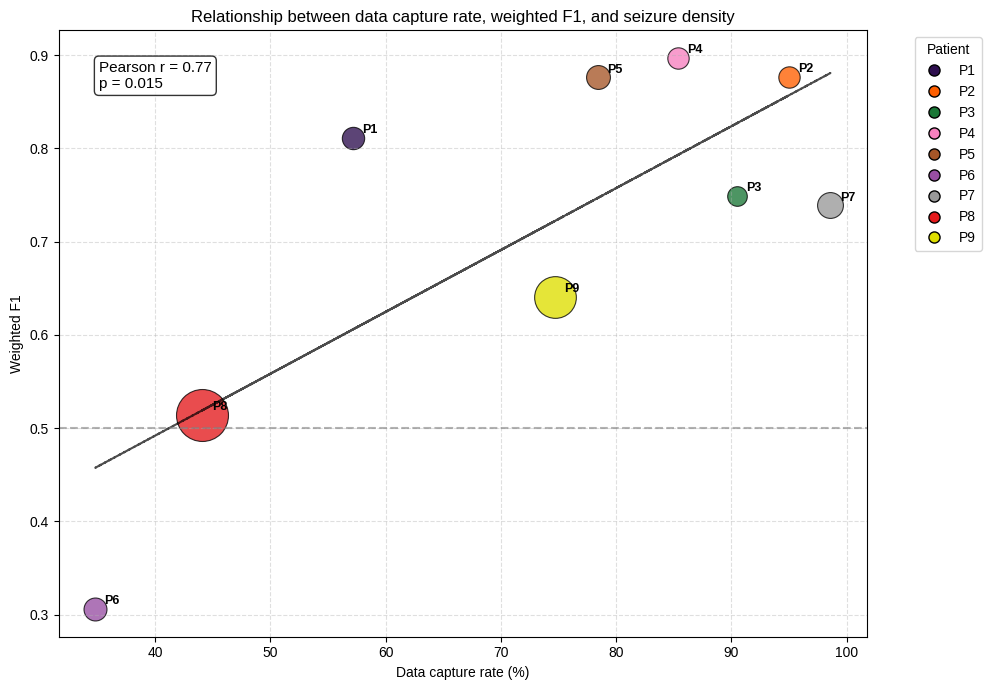

SVG saved in: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/src/test_and_develop/2_Feature_extraction/bubble_data_capture_weighted_f1_pearson_CB_palette_2026-06-29.svg


In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from pathlib import Path
from datetime import date

# ============================================================
# Bubble scatter plot
# X = Data capture rate (%)
# Y = Weighted F1
# Bubble size = Seizure density
# Colour = Patient number
# Label = Patient number
# + Pearson correlation
# ============================================================

patient_number_map = {
    "10OXG": "P1",
    "1JSZ6": "P2",
    "3ZL8B": "P3",
    "F88R2": "P4",
    "FP628": "P5",
    "JYXFE": "P6",
    "PN12G": "P7",
    "RQXZ1": "P8",
    "XB47Y": "P9"
}

patient_order = ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8", "P9"]

CB_color_cycle = [
    "#2E0F4F",  # P1 - very dark violet
    "#FF5F00",  # P2 - very bright orange
    "#1B7837",  # P3 - dark green
    "#f781bf",  # P4 - pink
    "#a65628",  # P5 - brown
    "#984ea3",  # P6 - purple
    "#999999",  # P7 - grey
    "#e41a1c",  # P8 - red
    "#dede00"   # P9 - yellow
]

patient_colors = {
    patient: CB_color_cycle[i]
    for i, patient in enumerate(patient_order)
}

df_plot = df_merged.copy()

# Keep only rows needed for this plot/correlation
df_plot = df_plot.dropna(
    subset=["Patient ID", "Data capture rate, %", "Weighted F1", "Seizure density"]
)

# Replace original patient IDs with assigned patient numbers
df_plot["Patient"] = df_plot["Patient ID"].map(patient_number_map)

# Optional check: identify unmapped patients
unmapped_patients = df_plot.loc[df_plot["Patient"].isna(), "Patient ID"].unique()
if len(unmapped_patients) > 0:
    print("Warning: these Patient IDs were not mapped:", unmapped_patients)

# Remove unmapped patients if any
df_plot = df_plot.dropna(subset=["Patient"])

# Sort by assigned patient number
df_plot["Patient"] = pd.Categorical(
    df_plot["Patient"],
    categories=patient_order,
    ordered=True
)

df_plot = df_plot.sort_values("Patient")

# ============================================================
# Correlation: Data capture rate vs Weighted F1
# ============================================================

x = df_plot["Data capture rate, %"]
y = df_plot["Weighted F1"]

pearson_r, pearson_p = pearsonr(x, y)

print("Pearson correlation between data capture rate and Weighted F1:")
print(f"r = {pearson_r:.3f}, p = {pearson_p:.3f}")

# ============================================================
# Bubble size scaling
# matplotlib 's' is area, not radius
# ============================================================

density = df_plot["Seizure density"]

if density.max() == density.min():
    bubble_sizes = pd.Series(600, index=df_plot.index)
else:
    bubble_sizes = 200 + (
        (density - density.min()) / (density.max() - density.min())
    ) * 1200

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(10, 7))

for i, row in df_plot.iterrows():
    plt.scatter(
        row["Data capture rate, %"],
        row["Weighted F1"],
        s=bubble_sizes.loc[i],
        color=patient_colors[row["Patient"]],
        alpha=0.78,
        edgecolor="black",
        linewidth=0.8
    )

    plt.text(
        row["Data capture rate, %"] + 0.8,
        row["Weighted F1"] + 0.005,
        row["Patient"],
        fontsize=9,
        fontweight="bold"
    )

# ============================================================
# Linear trend line
# ============================================================

m, b = np.polyfit(x, y, 1)

plt.plot(
    x,
    m * x + b,
    linestyle="--",
    color="black",
    alpha=0.7,
    label="Linear trend"
)

# ============================================================
# Correlation annotation inside plot
# ============================================================

plt.text(
    0.05,
    0.95,
    f"Pearson r = {pearson_r:.2f}\np = {pearson_p:.3f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.xlabel("Data capture rate (%)")
plt.ylabel("Weighted F1")
plt.title("Relationship between data capture rate, weighted F1, and seizure density")

plt.grid(True, linestyle="--", alpha=0.4)

# Optional reference line
plt.axhline(0.5, linestyle="--", color="grey", alpha=0.6)

# ============================================================
# Colour legend
# ============================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=patient,
        markerfacecolor=patient_colors[patient],
        markeredgecolor="black",
        markersize=8
    )
    for patient in patient_order
]

plt.legend(
    handles=legend_handles,
    title="Patient",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()

# ============================================================
# Save as SVG in current notebook folder
# ============================================================

today = date.today().strftime("%Y-%m-%d")
output_path = Path.cwd() / f"bubble_data_capture_weighted_f1_pearson_CB_palette_{today}.svg"

plt.savefig(output_path, format="svg", bbox_inches="tight")

plt.show()

print(f"SVG saved in: {output_path}")

Pearson correlation between data capture rate and Best accuracy:
r = 0.757, p = 0.018


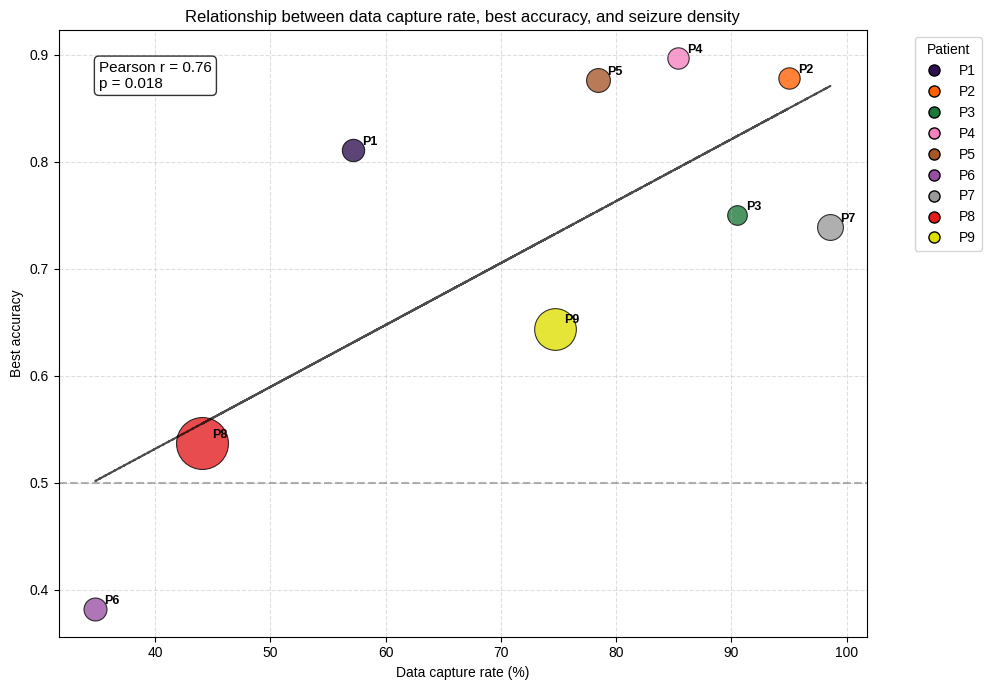

SVG saved in: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/src/test_and_develop/2_Feature_extraction/bubble_data_capture_best_accuracy_pearson_CB_palette_2026-06-29.svg


In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from pathlib import Path
from datetime import date

# ============================================================
# Bubble scatter plot
# X = Data capture rate (%)
# Y = Best accuracy
# Bubble size = Seizure density
# Colour = Patient number
# Label = Patient number
# + Pearson correlation
# ============================================================

patient_number_map = {
    "10OXG": "P1",
    "1JSZ6": "P2",
    "3ZL8B": "P3",
    "F88R2": "P4",
    "FP628": "P5",
    "JYXFE": "P6",
    "PN12G": "P7",
    "RQXZ1": "P8",
    "XB47Y": "P9"
}

patient_order = ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8", "P9"]

CB_color_cycle = [
    "#2E0F4F",  # P1 - very dark violet
    "#FF5F00",  # P2 - very bright orange
    "#1B7837",  # P3 - dark green
    "#f781bf",  # P4 - pink
    "#a65628",  # P5 - brown
    "#984ea3",  # P6 - purple
    "#999999",  # P7 - grey
    "#e41a1c",  # P8 - red
    "#dede00"   # P9 - yellow
]

patient_colors = {
    patient: CB_color_cycle[i]
    for i, patient in enumerate(patient_order)
}

df_plot = df_merged.copy()

# Keep only rows needed for this plot/correlation
df_plot = df_plot.dropna(
    subset=["Patient ID", "Data capture rate, %", "Best accuracy", "Seizure density"]
)

# Replace original patient IDs with assigned patient numbers
df_plot["Patient"] = df_plot["Patient ID"].map(patient_number_map)

# Optional check: identify unmapped patients
unmapped_patients = df_plot.loc[df_plot["Patient"].isna(), "Patient ID"].unique()
if len(unmapped_patients) > 0:
    print("Warning: these Patient IDs were not mapped:", unmapped_patients)

# Remove unmapped patients if any
df_plot = df_plot.dropna(subset=["Patient"])

# Sort by assigned patient number
df_plot["Patient"] = pd.Categorical(
    df_plot["Patient"],
    categories=patient_order,
    ordered=True
)

df_plot = df_plot.sort_values("Patient")

# ============================================================
# Correlation: Data capture rate vs Best accuracy
# ============================================================

x = df_plot["Data capture rate, %"]
y = df_plot["Best accuracy"]

pearson_r, pearson_p = pearsonr(x, y)

print("Pearson correlation between data capture rate and Best accuracy:")
print(f"r = {pearson_r:.3f}, p = {pearson_p:.3f}")

# ============================================================
# Bubble size scaling
# matplotlib 's' is area, not radius
# ============================================================

density = df_plot["Seizure density"]

if density.max() == density.min():
    bubble_sizes = pd.Series(600, index=df_plot.index)
else:
    bubble_sizes = 200 + (
        (density - density.min()) / (density.max() - density.min())
    ) * 1200

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(10, 7))

for i, row in df_plot.iterrows():
    plt.scatter(
        row["Data capture rate, %"],
        row["Best accuracy"],
        s=bubble_sizes.loc[i],
        color=patient_colors[row["Patient"]],
        alpha=0.78,
        edgecolor="black",
        linewidth=0.8
    )

    plt.text(
        row["Data capture rate, %"] + 0.8,
        row["Best accuracy"] + 0.005,
        row["Patient"],
        fontsize=9,
        fontweight="bold"
    )

# ============================================================
# Linear trend line
# ============================================================

m, b = np.polyfit(x, y, 1)

plt.plot(
    x,
    m * x + b,
    linestyle="--",
    color="black",
    alpha=0.7
)

# ============================================================
# Correlation annotation inside plot
# ============================================================

plt.text(
    0.05,
    0.95,
    f"Pearson r = {pearson_r:.2f}\np = {pearson_p:.3f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.xlabel("Data capture rate (%)")
plt.ylabel("Best accuracy")
plt.title("Relationship between data capture rate, best accuracy, and seizure density")

plt.grid(True, linestyle="--", alpha=0.4)

# Optional reference line
plt.axhline(0.5, linestyle="--", color="grey", alpha=0.6)

# ============================================================
# Colour legend
# ============================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=patient,
        markerfacecolor=patient_colors[patient],
        markeredgecolor="black",
        markersize=8
    )
    for patient in patient_order
]

plt.legend(
    handles=legend_handles,
    title="Patient",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()

# ============================================================
# Save as SVG in current notebook folder
# ============================================================

today = date.today().strftime("%Y-%m-%d")
output_path = Path.cwd() / f"bubble_data_capture_best_accuracy_pearson_CB_palette_{today}.svg"

plt.savefig(output_path, format="svg", bbox_inches="tight")

plt.show()

print(f"SVG saved in: {output_path}")

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

# ============================================================
# Bubble scatter plot
# X = Data capture rate (%)
# Y = Proportion of significant and large-effect features (%)
# Bubble size = Seizure density
# Colour = Patient ID
# Label = Patient ID
# + Pearson correlation
# ============================================================

# Merge recording/performance metadata with feature-summary table
df_plot = df_merged[
    ["Patient ID", "Data capture rate, %", "Seizure density"]
].merge(
    thesis_table,
    left_on="Patient ID",
    right_on="patient_id",
    how="inner"
)

# Keep only rows needed for this plot/correlation
df_plot = df_plot.dropna(
    subset=[
        "Patient ID",
        "Data capture rate, %",
        "Seizure density",
        "prop_sig_and_large_effect"
    ]
)

# Sort only to keep plotting/legend consistent
df_plot = df_plot.sort_values("Patient ID")

# ============================================================
# Correlation: Data capture rate vs prop_sig_and_large_effect
# ============================================================

x = df_plot["Data capture rate, %"]
y = df_plot["prop_sig_and_large_effect"]

pearson_r, pearson_p = pearsonr(x, y)

print("Pearson correlation between data capture rate and proportion of significant and large-effect features:")
print(f"r = {pearson_r:.3f}, p = {pearson_p:.3f}")

# ============================================================
# Colorblind-friendly palette: matplotlib tab10
# ============================================================

patients = df_plot["Patient ID"].tolist()
cmap = plt.get_cmap("tab10")

patient_colors = {
    patient: cmap(i % 10)
    for i, patient in enumerate(patients)
}

# ============================================================
# Bubble size scaling
# matplotlib 's' is area, not radius
# ============================================================

density = df_plot["Seizure density"]

if density.max() == density.min():
    bubble_sizes = np.repeat(600, len(density))
else:
    bubble_sizes = 200 + (
        (density - density.min()) / (density.max() - density.min())
    ) * 1200

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(10, 7))

for idx, row in df_plot.iterrows():
    pos = df_plot.index.get_loc(idx)

    plt.scatter(
        row["Data capture rate, %"],
        row["prop_sig_and_large_effect"],
        s=bubble_sizes[pos],
        color=patient_colors[row["Patient ID"]],
        alpha=0.75,
        edgecolor="black",
        linewidth=0.8
    )
    
    plt.text(
        row["Data capture rate, %"] + 0.8,
        row["prop_sig_and_large_effect"] + 1,
        row["Patient ID"],
        fontsize=9
    )

# ============================================================
# Optional trend line
# ============================================================

m, b = np.polyfit(x, y, 1)

plt.plot(
    x,
    m * x + b,
    linestyle="--",
    color="black",
    alpha=0.7
)

# ============================================================
# Correlation annotation inside plot
# ============================================================

plt.text(
    0.05,
    0.95,
    f"Pearson r = {pearson_r:.2f}\np = {pearson_p:.3f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.xlabel("Data capture rate (%)")
plt.ylabel("Significant and large-effect features (%)")
plt.title("Relationship between data capture rate and significant large-effect features")

plt.grid(True, linestyle="--", alpha=0.4)

# Optional reference line
plt.axhline(50, linestyle="--", color="grey", alpha=0.6)

# ============================================================
# Color legend only
# ============================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=patient,
        markerfacecolor=patient_colors[patient],
        markeredgecolor="black",
        markersize=8
    )
    for patient in patients
]

plt.legend(
    handles=legend_handles,
    title="Patient ID",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()

NameError: name 'thesis_table' is not defined

Pearson correlation between data capture rate and proportion of significant features:
r = 0.704, p = 0.034


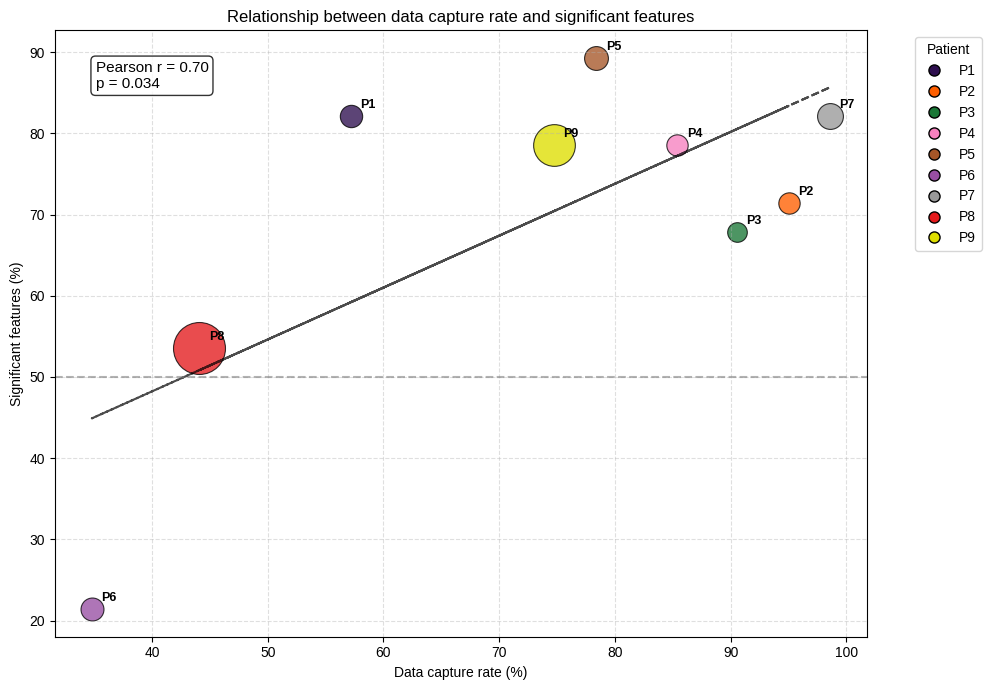

SVG saved in: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/src/test_and_develop/2_Feature_extraction/bubble_data_capture_significant_features_pearson_CB_palette_2026-06-29.svg


In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from pathlib import Path
from datetime import date

# ============================================================
# Bubble scatter plot
# X = Data capture rate (%)
# Y = Proportion of significant features (%)
# Bubble size = Seizure density
# Colour = Patient number
# Label = Patient number
# + Pearson correlation
# ============================================================

patient_number_map = {
    "10OXG": "P1",
    "1JSZ6": "P2",
    "3ZL8B": "P3",
    "F88R2": "P4",
    "FP628": "P5",
    "JYXFE": "P6",
    "PN12G": "P7",
    "RQXZ1": "P8",
    "XB47Y": "P9"
}

patient_order = ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8", "P9"]

CB_color_cycle = [
    "#2E0F4F",  # P1 - very dark violet
    "#FF5F00",  # P2 - very bright orange
    "#1B7837",  # P3 - dark green
    "#f781bf",  # P4 - pink
    "#a65628",  # P5 - brown
    "#984ea3",  # P6 - purple
    "#999999",  # P7 - grey
    "#e41a1c",  # P8 - red
    "#dede00"   # P9 - yellow
]

patient_colors = {
    patient: CB_color_cycle[i]
    for i, patient in enumerate(patient_order)
}

df_plot = df_merged[
    ["Patient ID", "Data capture rate, %", "Seizure density"]
].merge(
    thesis_table,
    left_on="Patient ID",
    right_on="patient_id",
    how="inner"
)

df_plot = df_plot.dropna(
    subset=[
        "Patient ID",
        "Data capture rate, %",
        "Seizure density",
        "prop_significant_features"
    ]
)

# Replace original patient IDs with assigned patient numbers
df_plot["Patient"] = df_plot["Patient ID"].map(patient_number_map)

# Optional check: identify unmapped patients
unmapped_patients = df_plot.loc[df_plot["Patient"].isna(), "Patient ID"].unique()
if len(unmapped_patients) > 0:
    print("Warning: these Patient IDs were not mapped:", unmapped_patients)

# Remove unmapped patients if any
df_plot = df_plot.dropna(subset=["Patient"])

# Sort by assigned patient number
df_plot["Patient"] = pd.Categorical(
    df_plot["Patient"],
    categories=patient_order,
    ordered=True
)

df_plot = df_plot.sort_values("Patient")

# ============================================================
# Correlation: Data capture rate vs significant features
# ============================================================

x = df_plot["Data capture rate, %"]
y = df_plot["prop_significant_features"]

pearson_r, pearson_p = pearsonr(x, y)

print("Pearson correlation between data capture rate and proportion of significant features:")
print(f"r = {pearson_r:.3f}, p = {pearson_p:.3f}")

# ============================================================
# Bubble size scaling
# ============================================================

density = df_plot["Seizure density"]

if density.max() == density.min():
    bubble_sizes = pd.Series(600, index=df_plot.index)
else:
    bubble_sizes = 200 + (
        (density - density.min()) / (density.max() - density.min())
    ) * 1200

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(10, 7))

for i, row in df_plot.iterrows():
    plt.scatter(
        row["Data capture rate, %"],
        row["prop_significant_features"],
        s=bubble_sizes.loc[i],
        color=patient_colors[row["Patient"]],
        alpha=0.78,
        edgecolor="black",
        linewidth=0.8
    )

    plt.text(
        row["Data capture rate, %"] + 0.8,
        row["prop_significant_features"] + 1,
        row["Patient"],
        fontsize=9,
        fontweight="bold"
    )

# ============================================================
# Trend line
# ============================================================

m, b = np.polyfit(x, y, 1)

plt.plot(
    x,
    m * x + b,
    linestyle="--",
    color="black",
    alpha=0.7
)

# ============================================================
# Correlation annotation
# ============================================================

plt.text(
    0.05,
    0.95,
    f"Pearson r = {pearson_r:.2f}\np = {pearson_p:.3f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.xlabel("Data capture rate (%)")
plt.ylabel("Significant features (%)")
plt.title("Relationship between data capture rate and significant features")

plt.grid(True, linestyle="--", alpha=0.4)

# Optional reference line
plt.axhline(50, linestyle="--", color="grey", alpha=0.6)

# ============================================================
# Colour legend
# ============================================================

present_patients = df_plot["Patient"].dropna().tolist()

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=patient,
        markerfacecolor=patient_colors[patient],
        markeredgecolor="black",
        markersize=8
    )
    for patient in present_patients
]

plt.legend(
    handles=legend_handles,
    title="Patient",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()

# ============================================================
# Save as SVG in current notebook folder
# ============================================================

today = date.today().strftime("%Y-%m-%d")
output_path = Path.cwd() / f"bubble_data_capture_significant_features_pearson_CB_palette_{today}.svg"

plt.savefig(output_path, format="svg", bbox_inches="tight")

plt.show()

print(f"SVG saved in: {output_path}")

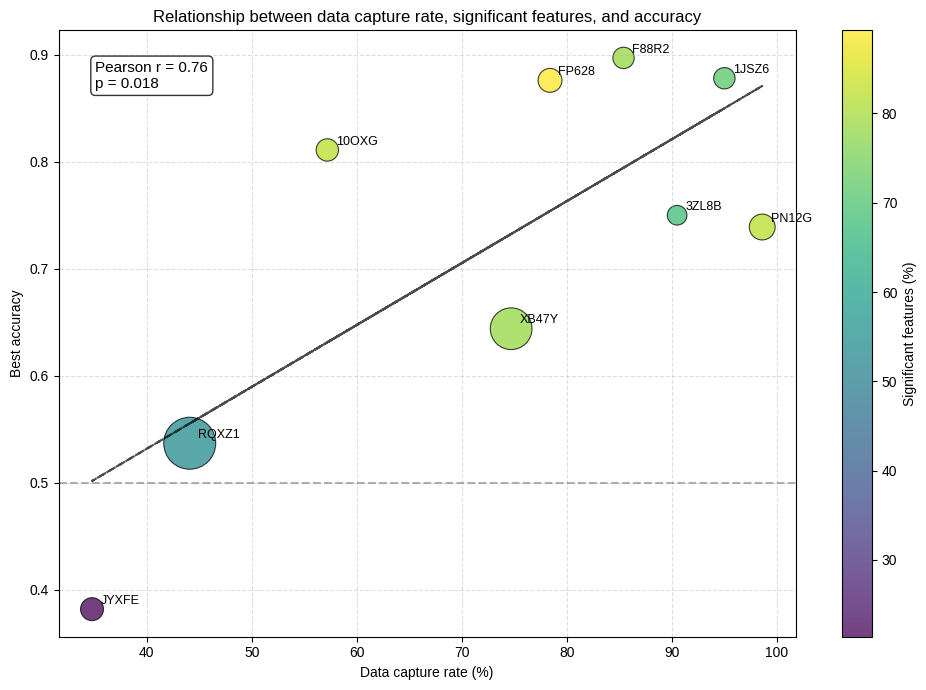

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

df_plot = df_merged[
    ["Patient ID", "Data capture rate, %", "Seizure density", "Best accuracy"]
].merge(
    thesis_table[["patient_id", "prop_significant_features"]],
    left_on="Patient ID",
    right_on="patient_id",
    how="inner"
)

df_plot = df_plot.dropna(
    subset=[
        "Patient ID",
        "Data capture rate, %",
        "Seizure density",
        "Best accuracy",
        "prop_significant_features"
    ]
)

df_plot = df_plot.sort_values("Patient ID")

x = df_plot["Data capture rate, %"]
y = df_plot["Best accuracy"]
color_values = df_plot["prop_significant_features"]

pearson_r, pearson_p = pearsonr(x, y)

density = df_plot["Seizure density"]

if density.max() == density.min():
    bubble_sizes = np.repeat(600, len(density))
else:
    bubble_sizes = 200 + (
        (density - density.min()) / (density.max() - density.min())
    ) * 1200

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    x,
    y,
    s=bubble_sizes,
    c=color_values,
    cmap="viridis",
    alpha=0.75,
    edgecolor="black",
    linewidth=0.8
)

for _, row in df_plot.iterrows():
    plt.text(
        row["Data capture rate, %"] + 0.8,
        row["Best accuracy"] + 0.005,
        row["Patient ID"],
        fontsize=9
    )

# Linear trend line
m, b = np.polyfit(x, y, 1)

plt.plot(
    x,
    m * x + b,
    linestyle="--",
    color="black",
    alpha=0.7
)

# Correlation annotation
plt.text(
    0.05,
    0.95,
    f"Pearson r = {pearson_r:.2f}\np = {pearson_p:.3f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

cbar = plt.colorbar(scatter)
cbar.set_label("Significant features (%)")

plt.xlabel("Data capture rate (%)")
plt.ylabel("Best accuracy")
plt.title("Relationship between data capture rate, significant features, and accuracy")

plt.grid(True, linestyle="--", alpha=0.4)
plt.axhline(0.5, linestyle="--", color="grey", alpha=0.6)

plt.tight_layout()
plt.show()

In [25]:
import statsmodels.api as sm

X = df_plot[["Data capture rate, %", "prop_significant_features"]]
X = sm.add_constant(X)

y = df_plot["Best accuracy"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          Best accuracy   R-squared:                       0.781
Model:                            OLS   Adj. R-squared:                  0.708
Method:                 Least Squares   F-statistic:                     10.69
Date:                Tue, 23 Jun 2026   Prob (F-statistic):             0.0105
Time:                        20:15:04   Log-Likelihood:                 10.304
No. Observations:                   9   AIC:                            -14.61
Df Residuals:                       6   BIC:                            -14.02
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

/home/tperezsanchez/micromamba/envs/domain_expansion/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [26]:
from scipy.stats import pearsonr

r, p = pearsonr(
    df_plot["Data capture rate, %"],
    df_plot["prop_significant_features"]
)

print(f"Correlation between data capture rate and significant features:")
print(f"r = {r:.3f}, p = {p:.3f}")

Correlation between data capture rate and significant features:
r = 0.704, p = 0.034


In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X = df_plot[["Data capture rate, %", "prop_significant_features"]]
X = sm.add_constant(X)

vif = pd.DataFrame()
vif["variable"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif

,variable,VIF
0,const,15.198612
1,"Data capture rate, %",1.980444
2,prop_significant_features,1.980444
